In [172]:
import os
import sys
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

import seaborn as sns
import scipy.stats as stats 

sys.path.append(os.path.abspath("./stats/OutcomePrediction/utils"))
import aimtbi_constants
import aimtbi_helper_functions

%load_ext autoreload
%autoreload 2
from matplotlib.font_manager import FontProperties
bold_font = FontProperties(family='helvetica', weight='bold')
normal_font = FontProperties(family='helvetica', weight='normal')
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
from matplotlib.font_manager import findfont, FontProperties
font = FontProperties(family='helvetica')
print(font.get_weight())

bold


In [ ]:
data = pd.read_excel(r'/users/koen_phd/documents/phd/biomarkers/mirna/analysis_data_15_05.xlsx')

In [3]:
import random
#randomly select 10 seeds between 1 and 1000
#set the seed for reproducibility
random.seed(42)
#42 is the answer to the ultimate question of life, the universe, and everything
seeds = random.sample(range(1, 1000), 10,)
print(seeds)

[655, 115, 26, 760, 282, 251, 229, 143, 755, 105]


In [209]:
#code for plotting
from sklearn.metrics import auc, roc_curve
def plot_mean_roc(fold_roc_data, title='Mean ROC Curve', color='blue'):
    """
    Plots a mean ROC curve with ±1 standard deviation shading.

    Parameters:
        fold_roc_data (list of dict): Each dict must contain 'fpr' and 'tpr' arrays for a fold.
        title (str): Title of the plot.
        color (str): Color for the ROC line.
    """
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []

    for fold in fold_roc_data:
        interp_tpr = np.interp(mean_fpr, fold['specificities']['raw']['fpr'], fold['specificities']['raw']['tpr'])
        interp_tpr[0] = 0.0  # enforce start at 0
        tprs.append(interp_tpr)

    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)

    plt.figure(figsize=(7, 5))
    plt.plot(mean_fpr, mean_tpr, color=color, label=f'Mean ROC (AUC = {mean_auc:.2f})')
    plt.fill_between(mean_fpr,
                     np.maximum(mean_tpr - std_tpr, 0),
                     np.minimum(mean_tpr + std_tpr, 1),
                     color=color, alpha=0.2, label='±1 SD')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_aggregated_roc(fold_roc_dict, title='Aggregated ROC Curve', colors=None, figsize = [], save = False, save_location = None):

    n_curves = len(fold_roc_dict)
    viridis_points = np.linspace(0.7, 0.9, n_curves)
    base_colors = [cm.viridis(p) for p in viridis_points]
    colors = [lighten_color(c, amount=0.2) for c in base_colors]

    figsize_inches = (figsize[0] / 25.4, figsize[1] / 25.4)

    plt.figure(figsize=figsize_inches, dpi=300)
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')

    legend_elements = []


    for (miRNA_name, fold_roc_data), color in zip(fold_roc_dict.items(), colors):

        all_y_true = []
        all_y_pred = []

        for fold in fold_roc_data:
            y_pred = fold['raw_pred']['y_pred_prob']
            y_test = fold['raw_pred']['y_test']
            all_y_true.append(y_test)
            all_y_pred.append(y_pred)

        all_y_true = np.concatenate(all_y_true)
        all_y_pred = np.concatenate(all_y_pred)

        fpr, tpr, _ = roc_curve(all_y_true, all_y_pred)
        roc_auc = auc(fpr, tpr)

        # Calculate confidence intervals using bootstrapping
        n_bootstraps = 1000
        bootstrapped_aucs = []
        bootstrapped_tprs = []
        
        for _ in range(n_bootstraps):
            # Bootstrap indices
            indices = np.random.randint(0, len(all_y_true), len(all_y_true))
            if len(np.unique(all_y_true[indices])) < 2:
                continue
                
            # Calculate ROC for this bootstrap
            fpr_boot, tpr_boot, _ = roc_curve(all_y_true[indices], all_y_pred[indices])
            bootstrapped_aucs.append(auc(fpr_boot, tpr_boot))
            
            # Interpolate tpr to match original fpr points
            interp_tpr = np.interp(fpr, fpr_boot, tpr_boot)
            bootstrapped_tprs.append(interp_tpr)
        
        # Calculate confidence intervals
        bootstrapped_tprs = np.array(bootstrapped_tprs)
        tpr_lower = np.percentile(bootstrapped_tprs, 2.5, axis=0)
        tpr_upper = np.percentile(bootstrapped_tprs, 97.5, axis=0)
        
        # Ensure curves start at 0,0
        fpr = np.insert(fpr, 0, 0.0)
        tpr = np.insert(tpr, 0, 0.0)
        tpr_lower = np.insert(tpr_lower, 0, 0.0)
        tpr_upper = np.insert(tpr_upper, 0, 0.0)
        
        # Plot mean curve and confidence interval
        plt.plot(fpr, tpr, color=color, lw=2, 
                label=f'{miRNA_name} (AUC = {roc_auc:.2f})')
        
        if len(miRNA_name.split(',')) > 1:

            plt.fill_between(fpr, tpr_lower, tpr_upper, color=color, alpha=0.2)

        legend_elements.append(Line2D([0], [0], color=color, lw=2, label=f"{miRNA_name.replace('hsa-', '').replace('_gose', '')} (AUC = {roc_auc:.2f})"))

    plt.xlim([0, 1])
    plt.ylim([0, 1.1])
    
    # Style adjustments
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.yticks(fontweight='normal')
    plt.xticks(fontweight='normal')
    # plt.title(title)
    legend = plt.legend(loc='lower right', handles=legend_elements, fontsize=12, edgecolor='black', fancybox=False)
    for text in legend.get_texts():
        text.set_fontweight('normal') 
    
    # Remove grid and top/right spines
    plt.grid(False)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()

    if save:
        plt.savefig(save_location, dpi=300, bbox_inches='tight')

    plt.show()

def plot_boxplot(df1, df2, df3, biomarkers, group_1_name, group_2_name, group_3_name, margin_dict = {'left': 0.1, 'right': 0.04, 'top': 0.05, 'bottom': 0.05, 'h_spacing': 0.05, 'v_spacing': 0.06}, break_thresholds = None, colors = None, figsize = (200, 160), figsize_unit = 'mm', dpi=300, save=False, save_location=None):
    """
    Create plots with optional broken y-axes for biomarkers with outliers.
    """
    # Convert figure size to inches
    if figsize_unit.lower() == 'mm':
        figsize_inches = (figsize[0] / 25.4, figsize[1] / 25.4)
    elif figsize_unit.lower() == 'cm':
        figsize_inches = (figsize[0] / 2.54, figsize[1] / 2.54)
    else:
        figsize_inches = figsize
    
    # Setup plot
    n_rows, n_cols = 2, 3
    fig = plt.figure(figsize=figsize_inches, dpi=dpi)

    base_color = plt.cm.viridis(0.8)
    pastel_viridis = [lighten_color(base_color, amount=0.2 + 0.6 * (i / (3-1))) for i in range(3)]
    colors = pastel_viridis[::-1]

    left_margin = margin_dict['left'] 
    right_margin = margin_dict['right']
    top_margin = margin_dict['top']
    bottom_margin = margin_dict['bottom']
    h_spacing = margin_dict['h_spacing']
    v_spacing = margin_dict['v_spacing'] 

    available_width = (1.0 - left_margin - right_margin - (n_cols - 1) * h_spacing) / n_cols
    available_height = (1.0 - top_margin - bottom_margin - (n_rows - 1) * v_spacing) / n_rows
    
    axes = []

    for idx, biomarker in enumerate(biomarkers):
        row, col = idx // n_cols, idx % n_cols
        
        # Calculate base position for this plot
        base_x = left_margin + col * (available_width + h_spacing)
        base_y = 1.0 - top_margin - (row + 1) * (available_height + v_spacing)

        if break_thresholds and biomarker in break_thresholds:
            # For broken axis plots, split the available height
            break_ratio = 0.15  # 20% for top plot
            gap = 0.05  # 2% gap between broken parts

            top_height = available_height * break_ratio
            gap_height = available_height * gap
            bottom_height = available_height * (1 - break_ratio - gap)

            # Create two axes with fixed positions
            ax_top = fig.add_axes([base_x, 
                          base_y + bottom_height + gap_height, 
                          available_width, 
                          top_height])
    
            ax_bottom = fig.add_axes([base_x, 
                            base_y, 
                            available_width, 
                            bottom_height])
            axes.extend([ax_top, ax_bottom])
            
            # Get data
            data1 = df1[biomarker].dropna()
            data2 = df2[biomarker].dropna()
            data3 = df3[biomarker].dropna()
            data = [data1, data2, data3]
            positions = [1, 2, 3]
            
            threshold = break_thresholds[biomarker]
            max_val = max([d.max() for d in data])
            min_val = min([d.min() for d in data])
            
            # Calculate consistent padding
            bottom_range = threshold - min_val
            top_range = max_val - threshold
        
            top_lim = (threshold, max_val + top_range * 0.20)
            bottom_lim = (min_val - bottom_range * 0.05, threshold)
            
            for ax_part, ylim in [(ax_top, top_lim), (ax_bottom, bottom_lim)]:
                ax_part.set_ylim(ylim)
                
                # Plot data
                for pos, group_data, color in zip(positions, data, colors):
                    mask = (group_data >= ylim[0]) & (group_data <= ylim[1])
                    data_part = group_data[mask]
                    
                    if len(data_part) > 0:
                        if ax_part == ax_bottom:
                            q1 = np.percentile(data_part, 25)
                            median = np.percentile(data_part, 50)
                            q3 = np.percentile(data_part, 75)
                            
                            ax_part.hlines(q1, pos-0.25, pos+0.25, color='black', linewidth=1)
                            ax_part.hlines(q3, pos-0.25, pos+0.25, color='black', linewidth=1)
                            ax_part.hlines(median, pos-0.25, pos+0.25, color='black', linewidth=2)
                        
                        x = np.random.normal(pos, 0.05, size=len(data_part))
                        ax_part.scatter(x, data_part, alpha=0.9, color=color, s=70,
                                      edgecolors='black', linewidths=0.5)
                
                # Configure axes
                ax_part.set_xlim(0.5, 3.5)
                ax_part.spines['right'].set_visible(False)
                
                if ax_part == ax_bottom:
                    ax_part.set_xticks(positions)
                    ax_part.set_xticklabels([group1_name, group2_name, hc_name],
                                          fontsize=10, **bold_font)
                    ax_part.set_ylabel(f"{biomarker.replace('_dx', '').replace('hsa-', '')} RNA-Seq (TMM normalized)", fontsize=11, fontweight='bold')

                    if col == 0:
                        ax_part.yaxis.set_label_coords(-0.4, 0.625)
                    else:
                        ax_part.yaxis.set_label_coords(-0.3, 0.625)

                    ax_part.spines['top'].set_visible(False)
                    ax_part.spines['bottom'].set_visible(True)
                    ax_part.spines['left'].set_visible(True)
                else:
                    ax_part.set_xticks([])
                    ax_part.spines['top'].set_visible(False)
                    ax_part.spines['bottom'].set_visible(False)
                    ax_part.spines['left'].set_visible(True)
            
            # Add break marks
            # d = .008
            # kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1)
            # ax_top.plot((-d, +d), (-d, +d), **kwargs)
            # ax_top.plot((1-d, 1+d), (-d, +d), **kwargs)
            # kwargs.update(transform=ax_bottom.transAxes)
            # ax_bottom.plot((-d, +d), (1-d, 1+d), **kwargs)
            # ax_bottom.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
            
            ax_top.set_title(biomarkers[biomarker][1], fontsize=12, **bold_font, pad=12)
            
        else:
            # Regular plot
            ax = fig.add_axes([base_x, 
                          base_y, 
                          available_width, 
                          available_height])
            axes.append(ax)
            
            # Get data
            data1 = df1[biomarker].dropna()
            data2 = df2[biomarker].dropna()
            data3 = df3[biomarker].dropna()
            data = [data1, data2, data3]
            positions = [1, 2, 3]
            
            # Calculate quartiles and plot
            for pos, group_data, color in zip(positions, data, colors):
                if len(group_data) > 0:
                    q1 = np.percentile(group_data, 25)
                    median = np.percentile(group_data, 50)
                    q3 = np.percentile(group_data, 75)
                    
                    ax.hlines(q1, pos-0.25, pos+0.25, color='black', linewidth=1)
                    ax.hlines(q3, pos-0.25, pos+0.25, color='black', linewidth=1)
                    ax.hlines(median, pos-0.25, pos+0.25, color='black', linewidth=2)
                    
                    x = np.random.normal(pos, 0.05, size=len(group_data))
                    ax.scatter(x, group_data, alpha=0.9, color=color, s=70,
                             edgecolors='black', linewidths=0.5)
            
            # Customize plot
            ax.set_title(biomarker.replace('_dx', '').replace('hsa-', ''), fontsize=11, weight='bold', pad=12)
            ax.set_xticks(positions)
            ax.set_xticklabels([group_1_name, group_2_name, group_3_name], fontsize=10, weight='bold')
            ax.set_ylabel(f" RC RNA-Seq (TMM normalized)", weight='bold', fontsize=10)

            if col == 0:
                ax.yaxis.set_label_coords(-0.25, 0.5)
            else:
                ax.yaxis.set_label_coords(-0.25, 0.5)
            
            plt.setp(ax.get_xticklabels(), weight='bold', fontsize=10)
            plt.setp(ax.get_yticklabels(), fontproperties=normal_font, fontsize=10)
            
            for spine in ['left', 'bottom']:
                ax.spines[spine].set_visible(True)
                ax.spines[spine].set_linewidth(1)
                ax.spines[spine].set_color('black')
            
            for spine in ['top', 'right']:
                ax.spines[spine].set_visible(False)
            
            ax.patch.set_alpha(0.0)
            ax.grid(False)

    if save:
        plt.savefig(save_location, dpi=300, bbox_inches='tight')
    
    return fig, axes

def parse_biomarker_string(biomarker_string):
    biomarkers_dict = {}
    for item in biomarker_string.split(','):
        readable_name = item.replace('hsa-', '').replace('_ct', '')
        biomarkers_dict[item] = ['Read Count', readable_name]

    return biomarkers_dict

def calculate_false_negative_rate(individual_subset_results, biomarker_key, current_key_length):

    fp_counts = {}
    n_folds_current = len(individual_subset_results[current_key_length][biomarker_key])

    for fold in individual_subset_results[current_key_length][biomarker_key]:
        y_pred = fold['raw_pred']['y_pred']

        false_negatives = (fold['raw_pred']['y_test'] == 1) & (y_pred == 0)
        fp_indices = fold['raw_pred']['y_test'][false_negatives].index.tolist()

        for idx in fp_indices:
            fp_counts[idx] = fp_counts.get(idx, 0) + 1

    return fp_counts, n_folds_current

def stratify_predictions_by_ct_injury_type(individual_subset_results, biomarker_key, dataframe):
    biomarkers = biomarker_key.split(',')
    aggregated_fp_counts = {}

    # Calculate false negative rates for individual biomarkers
    for biomarker in biomarkers:
        fp_counts, n_folds = calculate_false_negative_rate(individual_subset_results, biomarker, 1)
        aggregated_fp_counts[biomarker] = {'fp_counts': fp_counts, 'n_folds': n_folds}

    # Calculate false negative rates for combined biomarkers if more than one
    if len(biomarkers) > 1:
        fp_counts, n_folds = calculate_false_negative_rate(individual_subset_results, biomarker_key, len(biomarkers))
        aggregated_fp_counts[biomarker_key] = {'fp_counts': fp_counts, 'n_folds': n_folds}

    # Prepare data
    temp_data = dataframe.copy()
    temp_data.dropna(subset=['ct_injury_type_1'], inplace=True)
    
    # Create count dictionary
    count_dict = {value: {'case_count': count} for value, count in temp_data['ct_injury_type_1'].value_counts().items()}

    # Process each biomarker
    for biomarker in biomarkers:
        # Add false negative counts to temp_data
        temp_data['false_negative_count_' + biomarker] = temp_data.index.map(aggregated_fp_counts[biomarker]['fp_counts'])
        
        # Aggregate by ct_injury_type
        temp_agg = temp_data.groupby('ct_injury_type_1').agg({
            'false_negative_count_' + biomarker: 'sum'
        }).reset_index()
        
        # Add false negative counts and rates to count_dict
        for idx, row in temp_agg.iterrows():
            ct_type = row['ct_injury_type_1']
            count_dict[ct_type][f'false_negative_count_{biomarker}'] = row[f'false_negative_count_{biomarker}']
            count_dict[ct_type][f'fn_rate_{biomarker}'] = (
                count_dict[ct_type][f'false_negative_count_{biomarker}'] / 
                count_dict[ct_type]['case_count']
            )
            # Add false negative count per fold
            count_dict[ct_type][f'fn_per_fold_{biomarker}'] = (
                count_dict[ct_type][f'false_negative_count_{biomarker}'] / 
                aggregated_fp_counts[biomarker]['n_folds']
            )

            count_dict[ct_type][f'fn_per_case_per_fold_{biomarker}'] = (
                count_dict[ct_type][f'fn_rate_{biomarker}'] / 
                aggregated_fp_counts[biomarker]['n_folds']
            )

    # Process combined biomarkers if they exist
    if len(biomarkers) > 1:
        temp_data['false_negative_count_' + biomarker_key] = temp_data.index.map(aggregated_fp_counts[biomarker_key]['fp_counts'])
        temp_agg = temp_data.groupby('ct_injury_type_1').agg({
            'false_negative_count_' + biomarker_key: 'sum'
        }).reset_index()
        
        for idx, row in temp_agg.iterrows():
            ct_type = row['ct_injury_type_1']
            count_dict[ct_type][f'false_negative_count_{biomarker_key}'] = row[f'false_negative_count_{biomarker_key}']
            count_dict[ct_type][f'fn_rate_{biomarker_key}'] = (
                count_dict[ct_type][f'false_negative_count_{biomarker_key}'] / 
                count_dict[ct_type]['case_count']
            )
            # Add false negative count per fold for combined biomarkers
            count_dict[ct_type][f'fn_per_fold_{biomarker_key}'] = (
                count_dict[ct_type][f'false_negative_count_{biomarker_key}'] / 
                aggregated_fp_counts[biomarker_key]['n_folds']
            )

            count_dict[ct_type][f'fn_per_case_per_fold_{biomarker_key}'] = (
                count_dict[ct_type][f'fn_rate_{biomarker_key}'] / 
                aggregated_fp_counts[biomarker_key]['n_folds']
            )
    data = pd.DataFrame.from_dict(count_dict, orient='index')

    return data

def make_pretty_labels(columns):
    """
    Given a list of column names, return a dictionary mapping each column
    to a pretty miRNA label for plotting.
    """
    pretty_labels = {}
    for col in columns:
        # Remove prefix and suffix
        if col.startswith('fn_per_case_per_fold_'):
            base = col.replace('fn_per_case_per_fold_', '')
            # Handle combinations
            if ',' in base:
                parts = base.split(',')
                pretty = ' + '.join([p.replace('hsa-', '').replace('_ct', '') for p in parts])
            else:
                pretty = base.replace('hsa-', '').replace('_ct', '')
            pretty_labels[col] = pretty
        else:
            pretty_labels[col] = col  # fallback
    return pretty_labels

def lighten_color(color, amount=0.5):
    """
    Lightens the given color by mixing it with white.
    Input can be matplotlib color string, hex string, or RGB tuple.
    amount=0 returns original color, amount=1 returns white.
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = np.array(mc.to_rgb(c))
    white = np.array([1, 1, 1])
    return tuple((1 - amount) * c + amount * white)
    
def get_lightened_colormap(base_cmap, amount=0.5, N=256):
    # Sample the base colormap
    colors = [base_cmap(i / (N - 1)) for i in range(N)]
    # Lighten each color
    lightened_colors = [lighten_color(color, amount=amount) + (color[3],) if len(color) == 4 else lighten_color(color, amount=amount) for color in colors]
    return ListedColormap(lightened_colors)
  
def create_aggregated_barplot(data, biomarker_key, figsize = [12, 6], save = False, save_location = None):

    injury_type_map = {
    1.0: 'Contusion',
    2.0: 'EDH',
    3.0: 'SAB',
    4.0: 'SDH',
    5.0: 'Parenchymal bleed'
    }
    biomarkers = biomarker_key.split(',')

    if len(biomarkers) > 1:
        biomarkers.append(biomarker_key)

    index_columns = []

    for biomarker in biomarkers:
        index_columns.append(f'fn_per_case_per_fold_{biomarker}')

    print(index_columns)

    pretty_labels = make_pretty_labels(index_columns)
    print(pretty_labels)

    data['ct_injury_type_name'] = data.index.map(injury_type_map)

    plot_data = data[index_columns]
    plot_data = data.set_index('ct_injury_type_name')[index_columns]

    num_bars = plot_data.shape[1]
    # viridis_colors = cm.viridis([i  / (num_bars-1) for i in range(num_bars)])
    # pastel_viridis = [lighten_color(c, amount=0.5) for c in viridis_colors]

    base_color = plt.cm.viridis(0.8)
    pastel_viridis = [lighten_color(base_color, amount=0.2 + 0.6 * (i / (num_bars-1))) for i in range(num_bars)]

    figsize_inches = (figsize[0] / 25.4, figsize[1] / 25.4)
    fig, ax = plt.subplots(figsize=figsize_inches, dpi=300)

    plot_data.plot(kind='barh', ax=ax, width = 0.8, color = pastel_viridis)

# Customize the plot
    plt.xlabel('False Negative Rate (per case per fold)', fontsize=10)
    plt.ylabel('Head CT Lesion Type', fontsize=10)
    plt.yticks(fontweight='normal')
    plt.xticks(fontweight='normal')
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = [pretty_labels.get(label, label) for label in labels]
    legend = ax.legend(handles, new_labels, title='miRNA', bbox_to_anchor=(0.8, 1), loc='upper left', fontsize=10)
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_linewidth(1)
    legend.get_frame().set_boxstyle('Square')
    legend.get_frame().set_facecolor('white')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    if save:
        plt.savefig(save_location, dpi=300, bbox_inches='tight')


# Show the plot
    plt.show()

def getCorrelationValue(exp_var, variable2, exploratory_variables, cut_variables,  dataset, spec, covar, covar_variables):

    if ((exp_var in covar_variables) | (variable2 in covar_variables)) & spec:
        data = dataset.loc[(dataset[variable2].notna()) & (dataset[exp_var].notna())]
        result = partial_corr(data=data, x=variable2, y=exp_var, covar=covar, method='pearson')
        corr_value = result['r'].to_numpy()[0]
        p_value = result['p-val'].to_numpy()[0]

    else:
        if (exploratory_variables[exp_var] == 0) & (cut_variables[variable2] == 0):
            data = dataset.loc[(dataset[variable2].notna()) & (dataset[exp_var].notna())]
            result = stats.pearsonr(x=data[variable2], y=data[exp_var])
            corr_value = result.statistic
            p_value = result.pvalue
            # if result.pvalue < 0.1: print(result, exp_var, variable2)
        elif (exploratory_variables[exp_var] == 1) | (cut_variables[variable2] == 1):
            data = dataset.loc[(dataset[variable2].notna()) & (dataset[exp_var].notna())]
            result = stats.spearmanr(a=data[variable2], b=data[exp_var])
            corr_value = result.correlation
            p_value = result.pvalue
            # if result.pvalue < 0.1: print(result, exp_var, variable2)
        else:
            data = dataset.loc[(dataset[variable2].notna()) & (dataset[exp_var].notna())]
            result = stats.pointbiserialr(x=data[variable2], y=data[exp_var])
            corr_value = result.correlation
            p_value = result.pvalue
        
    return [corr_value, p_value]

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def makeHeatmap(dataset, exploratory_variables, exp_variable_cut, xtick_labels, ytick_labels, spec, saveFig, name, covar, covar_variables, figsize=[190, 100]):
    r_list = {}
    item_list = []
    p_list = {'combination':[], 'pvalue':[]}

    for init_variable in exploratory_variables:
        variable_list = []
        for variable_looped in exp_variable_cut:
            result = getCorrelationValue(init_variable, variable_looped, exploratory_variables, exp_variable_cut, dataset, spec, covar, covar_variables)
            variable_list.append(round(result[0], 2))
            p_list['combination'].append(f"{variable_looped}-{init_variable}")
            p_list['pvalue'].append(result[1])
        r_list[init_variable] = variable_list

    for variable_x in exp_variable_cut:
        item_list.append(variable_x)
    r_list['variables'] = item_list
    
    df = pd.DataFrame.from_dict(r_list)
    df.set_index("variables", inplace=True)
    figsize_inches = (figsize[0] / 25.4, figsize[1] / 25.4)
    light_viridis = get_lightened_colormap(cm.viridis, amount=0.2)

    fig, ax = plt.subplots(figsize=figsize_inches, dpi=300)

    cbar_ax = fig.add_axes([0.125, 0.08, 0.8, 0.03]) #Left, bottom, width, height

    hm = sns.heatmap(
        df, 
        annot=True, 
        linewidth=.3, 
        linecolor='black', 
        cmap=light_viridis, 
        ax=ax, 
        vmin=-.8, 
        vmax=.8, 
        cbar=True,
        cbar_ax=cbar_ax,  # <-- use the custom colorbar axis
        cbar_kws={'orientation': 'horizontal', 'label': 'Correlation coefficient'},
        annot_kws={'fontsize':10, 'fontweight':'normal'}, 
        mask=(df > -0.15) & (df < 0.15), 
        square=True 
    )

    print(ax.get_position())

    # cax = inset_axes(ax,
    #              width="3%",  # width of colorbar
    #              height="100%",  # height: 100% of the parent (ax)
    #              loc='bottom',
    #              borderpad=-4)


    # cb = plt.colorbar(hm.collections[0], cax=cax)
    # cb.set_label('Correlation coefficient')
    # cb.ax.tick_params(size=0)

    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.set_xticklabels(xtick_labels, weight='bold', fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="left", rotation_mode="anchor")
    ax.tick_params(labelsize=11, width=6)
    ax.set_yticklabels(ytick_labels, weight='bold', fontsize=9)
    ax.yaxis.set_ticks_position('none')
    ax.xaxis.set_ticks_position('none')
    ax.set_xlabel('')
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.3)

    for spine in cbar_ax.spines.values():
        spine.set_visible(False)

    for label in cbar_ax.get_xticklabels():
     label.set_fontweight('normal')

    if saveFig:
        fig.savefig(fname=name, dpi=300, bbox_inches='tight')

    return p_list

def getAdjustedPValue(q, k, values):
    adjustedlist = []
    for i in range(k):
        currentindex = i + 1
        current_value = values.tolist()[i]
        currentvalue = (current_value * k / currentindex)
        adjustedlist.append(currentvalue)
    
    return adjustedlist

def getSignificanceValue(q, k, values):
    significanceList = []
    for i in range(k):
        currentindex = i+1
        
        current_value = (currentindex / k) * q
        significanceList.append(current_value)

    return significanceList

def displayPValueAdjusted(p_list):
    p_dataframe = pd.DataFrame.from_dict(p_list)
    p_dataframe['time'] = p_dataframe['combination'].apply(lambda x: 0 if 'v1' in x else 1)
    acute = p_dataframe.loc[p_dataframe['time'] == 0]
    subacute = p_dataframe.loc[p_dataframe['time'] == 1]
    acute.sort_values(by=['pvalue'], axis=0, ascending=True, inplace=True)
    subacute.sort_values(by=['pvalue'], axis=0, ascending=True, inplace=True)
    acute['fdr_adjusted_p'] = getAdjustedPValue(0.05, len(acute['pvalue']), acute['pvalue'])
    print(display(acute))
    subacute['fdr_adjusted_p'] = getAdjustedPValue(0.05, len(subacute['pvalue']), subacute['pvalue'])
    subacute['significance_value'] = getSignificanceValue(0.05, len(subacute['pvalue']), subacute['pvalue'])
    print(display(subacute))

    return

def plotter(dataframe, subset_results, biomarker_key, dependent_variable = {'dv': '', 'dv_1': '', 'dv_2': '', 'dv_1_name': '', 'dv_2_name': ''}, plots = ['boxplot', 'roc_mean', 'roc_aggregated'], biomarkers = None, plot_details = None):
    
    naming_dict = parse_biomarker_string(biomarker_key)
    n_biomarkers = len(naming_dict)

    for plot in plots:
        if plot == 'boxplot':
            plot_boxplot(df1 = dataframe.loc[dataframe[dependent_variable['dv']] == dependent_variable['dv_1']],
                         df2 =dataframe.loc[dataframe[dependent_variable['dv']] == dependent_variable['dv_2']],
                         biomarkers=biomarkers,
                         group_1_name=dependent_variable['dv_1_name'],
                         group_2_name=dependent_variable['dv_2_name'] )
        elif plot == 'roc_mean':
            plot_mean_roc(subset_results[n_biomarkers][biomarker_key])
        elif plot == 'roc_aggregated':
            biomarkers = biomarker_key.split(',')
            biomarkers.append(biomarker_key)
            subset_results_dict = {}

            for biomarker in biomarkers:
                length = len(biomarker.split(','))
                print(length)
                if length == 0:
                    length + 1
                subset_results_dict[biomarker] = subset_results[length][biomarker]
        

            plot_aggregated_roc(subset_results_dict, figsize = plot_details['roc_aggregated']['figsize'], save = plot_details['roc_aggregated']['save'], save_location = plot_details['roc_aggregated']['save_location'])
        elif plot == 'barplot':
            data = stratify_predictions_by_ct_injury_type(subset_results, biomarker_key, dataframe)
            create_aggregated_barplot(data, biomarker_key, figsize = plot_details['barplot']['figsize'], save = plot_details['barplot']['save'], save_location = plot_details['barplot']['save_location'])

    return

In [ ]:
#Code necessary for running ensemble feature selection
from collections import Counter, defaultdict
import itertools
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix, roc_curve, auc, log_loss
from sklearn.model_selection import StratifiedKFold
import pickle

def best_threshold_v2(y_test, y_pred_prob, sensitivity_threshold = 0.95):

    outcome = {}

    #Will return the best specificity
    best_specificity = 0
    best_threshold = None
    best_sensitivity = None

    #Will only return the best specificity, threshold and sensitivity above set sensitivity threshold
    best_specificity_threshold = -np.inf
    best_threshold_threshold = None
    best_sensitivity_threshold = 0

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)



    for threshold in range(len(thresholds)):
        sensitivity = tpr[threshold]
        specificity = 1 - fpr[threshold]       
        
        if sensitivity >= sensitivity_threshold and specificity > best_specificity_threshold:
            best_specificity_threshold = specificity
            best_threshold_threshold = thresholds[threshold]
            best_sensitivity_threshold = sensitivity

        if specificity > best_specificity:
            best_specificity = specificity
            best_sensitivity = sensitivity
            best_threshold = thresholds[threshold]

    outcome['best_spec_@_theshold'] = {'best_specificity': best_specificity_threshold, 'best_threshold': best_threshold_threshold, 'best_sensitivity': best_sensitivity_threshold}
    outcome['best_spec'] = {'best_specificity': best_specificity, 'best_threshold': best_threshold, 'best_sensitivity': best_sensitivity}
    outcome['raw'] = {'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds}
    
    return outcome

def best_subset_logistic_regression_v2(X_train, y_train, X_test, y_test, predictors, max_subset_size = 5, sensitivity_threshold = 0.95):

    subset_results = []

    for current_subset_size in range(1, max_subset_size + 1):
        for subset in itertools.combinations(predictors, current_subset_size):
            subset = list(subset)
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train[subset])
            X_test_scaled = scaler.transform(X_test[subset])

            model = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
            model.fit(X_train_scaled, y_train)

            coefficients = dict(zip(subset, model.coef_[0]))

            y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
            y_pred = model.predict(X_test_scaled)
            metrics = calculate_metrics(y_test, y_pred, y_pred_prob)
            outcomes = best_threshold_v2(y_test, y_pred_prob, sensitivity_threshold)
            raw_pred = {'y_test': y_test, 'y_pred': y_pred, 'y_pred_prob': y_pred_prob}

            subset_results.append({
                "subset": subset,
                'num_features': current_subset_size,
                'metrics': metrics,
                'specificities': outcomes,
                'raw_pred': raw_pred,
                'coefficients': coefficients
            })

    return subset_results

def best_threshold(results, sensitivity_threshold = 1):
    result_df = pd.DataFrame(results)

    best_specificity = []
    best_threshold = []
    best_sensitivity = []

    for i in range(5):
        current_data = result_df.iloc[i]
        fpr, tpr, thresholds = roc_curve(current_data['y_test'], current_data['y_pred_prob'])
        max_specificity = -np.inf
        best_thresh = None
        best_sens = 0

        
    
        for j in range(len(thresholds)):
            sensitivity = tpr[j]
            specificity = 1 - fpr[j]       
        
            if sensitivity >= sensitivity_threshold and specificity > max_specificity:
                max_specificity = specificity
                best_thresh = thresholds[j]
                best_sens = sensitivity

        best_specificity.append(max_specificity)
        best_threshold.append(best_thresh)
        best_sensitivity.append(best_sens)
    
    return best_specificity, best_threshold, best_sensitivity

def calculate_metrics(y_true, y_pred, y_prob):
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn)  # Also called recall
    specificity = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    youden_index = sensitivity + specificity - 1

    n = y_true.shape[0]
    y_base = np.mean(y_true) * np.ones(n)

    LL_model = -log_loss(y_true, y_prob, normalize=True) * n
    LL_null = -log_loss(y_true, y_base, normalize=True) * n

    cox_r2 = 1 - np.exp((LL_null - LL_model) / n)
    r2_nagelkerke = cox_r2 / (1 - np.exp(LL_null / n)) if (1 - np.exp(LL_null / n)) != 0 else np.nan

    
    return {
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1 Score': f1,
        'AUC': auc,
        'Youden Index': youden_index,
        'FP': fp,
        'TP': tp,
        'TN': tn,
        'FN': fn,
        'Nagelkerke R2': r2_nagelkerke
    }

def boostrap_ensemble_feature_selection(X, y, n_iterations = 100, n_features = 10, stability_threshold = 0.6):
    feature_counts = Counter()

    #Standardize features
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    for i in range(n_iterations):
        X_temp, y_temp = resample(X_scaled, y, stratify=y, replace=True, random_state=i)

        selected_features = []

            # 1. RFE with Logistic Regression
        rfe = RFE(LogisticRegression(max_iter=1000, solver='liblinear'), n_features_to_select=n_features)
        rfe.fit(X_temp, y_temp)
        selected_features.extend(X.columns[rfe.support_])

        # 2. Random Forest
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_temp, y_temp)
        rf_top_idx = np.argsort(rf.feature_importances_)[-n_features:]
        selected_features.extend(X.columns[rf_top_idx])

        try:
            lasso = LassoCV(cv=3, max_iter=10000, tol=0.0001)
            lasso.fit(X_temp, y_temp)
            selected_features.extend(X.columns[lasso.coef_ != 0])
        except Exception as e:
            pass

        # 4. SelectKBest
        skb = SelectKBest(score_func=f_classif, k=n_features)
        skb.fit(X_temp, y_temp)
        selected_features.extend(X.columns[skb.get_support()])

        # Tally selected features
        feature_counts.update(selected_features)

    stability_df = pd.DataFrame.from_dict(feature_counts, orient='index', columns=['count'])
    stability_df['frequency'] = stability_df['count'] / n_iterations
    stability_df = stability_df.sort_values(by='frequency', ascending=False)

    stable_features = stability_df[stability_df['frequency'] >= stability_threshold].index.tolist()
    return stability_df, stable_features, feature_counts

def evaluating_model_feature_selection(X, y, n_splits = 5, n_iterations = 100, n_features = 10, random_state = 42):
    
    outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    selected_features = {}
    all_outcomes = []
    all_metrics = {}
    all_test_indices = {}

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        feature_df, stable_features_temp, feature_counts_temp = boostrap_ensemble_feature_selection(X_train, y_train, n_iterations, n_features, stability_threshold = 0.6)

        predictors = stable_features_temp[:n_features]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train[predictors])
        X_test_scaled = scaler.transform(X_test[predictors])

        model = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
        model.fit(X_train_scaled, y_train)
        
        y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
        y_pred = model.predict(X_test_scaled)
        metrics = calculate_metrics(y_test, y_pred, y_pred_prob)
        all_metrics[f'fold {fold_idx}'] = metrics
        all_outcomes.append({'y_test': y_test, 'y_pred': y_pred, 'y_pred_prob': y_pred_prob, 'indices': X.iloc[test_idx].index.tolist()})
        all_test_indices[f'fold {fold_idx}'] = X.iloc[test_idx].index.tolist()
        selected_features[f'fold {fold_idx}'] = feature_counts_temp

    return all_metrics, all_outcomes, all_test_indices, selected_features

def get_coefficients(coeffficient_list):
    coeff_dict = {}

    for d in coeffficient_list:
        for key, value in d.items():
            coeff_dict.setdefault(key, []).append(value)

    summary = {}
    for miRNA, values in coeff_dict.items():
        values = np.array(values)
        mean = np.mean(values)
        sem = stats.sem(values)
        ci = stats.t.interval(0.95, len(values)-1, loc=mean, scale=sem)
        summary[miRNA] = {
            'mean': round(mean, 4),
            '95% CI': (round(ci[0], 4), round(ci[1], 4))
        }
    return summary

def analyse_subset_results(all_results, max_subset_size):
    all_subsets = defaultdict(lambda: defaultdict(list))
    all_subsets_averages = defaultdict(dict)

    for result in all_results:
        for subset_info in result:
            size = subset_info['num_features']
            if size > max_subset_size:
                continue

            key = ','.join(sorted(subset_info['subset']))
            all_subsets[size][key].append({
                'metrics': subset_info['metrics'],
                'specificities': subset_info['specificities'],
                'raw_pred': subset_info['raw_pred'],
                'coefficients': subset_info['coefficients']
            })

    def mean_ci(arr):
        arr = np.array(arr)
        n = len(arr)
        if n == 0:
            return (None, (None, None))
        mean = arr.mean()
        if n == 1:
            return (round(mean, 3), (None, None))  # CI undefined for single value
        se = arr.std(ddof=1) / np.sqrt(n)
        t_score = stats.t.ppf(0.975, df=n - 1)
        ci = t_score * se
        return (
            round(mean, 3),
            (round(mean - ci, 3), round(mean + ci, 3))
        )

    for size, subsets in all_subsets.items():
        for key, evaluations in subsets.items():
            aucs = [e['metrics']['AUC'] for e in evaluations]
            specs = [e['metrics']['Specificity'] for e in evaluations]
            sens = [e['metrics']['Sensitivity'] for e in evaluations]
            best_specs = [e['specificities']['best_spec_@_theshold']['best_specificity'] for e in evaluations]
            best_sens = [e['specificities']['best_spec_@_theshold']['best_sensitivity'] for e in evaluations]
            best_thresh = [e['specificities']['best_spec_@_theshold']['best_threshold'] for e in evaluations]
            youden_index = [e['metrics']['Youden Index'] for e in evaluations]
            nagelkerke_r2 = [e['metrics']['Nagelkerke R2'] for e in evaluations]
            coefficients = [e['coefficients'] for e in evaluations]
            

            all_subsets_averages[size][key] = {
                'coefficients': get_coefficients(coefficients),
                'AUC': mean_ci(aucs),
                'Specificity': mean_ci(specs),
                'Sensitivity': mean_ci(sens),
                'Youden Index': mean_ci(youden_index),
                'Nagelkerke R2': mean_ci(nagelkerke_r2),
                'best_spec': mean_ci(best_specs),
                'best_sens@_best_spec': mean_ci(best_sens),
                'best_threshold@_best_spec': mean_ci(best_thresh),
                'times_selected': len(evaluations)
            }

    return dict(all_subsets_averages), all_subsets

def nested_ensemble_feature_selection_plus_evaluation(dataframe, start_index_mirna, end_index_mirna, dv, n_iterations, max_features, pickle_name, n_splits = 5, results = None, evaluation = False, max_subset_size = 3):
    miRNA_columns = dataframe.columns[start_index_mirna:end_index_mirna + 1]
    temp_data = dataframe.copy()

    y = temp_data[dv]
    X = temp_data[miRNA_columns]

    if results is None: 
        results = {}

        for seed in seeds:
            metrics_mirna, outcomes_mirna, all_test_indices_mirna, selected_features = evaluating_model_feature_selection(X, y, n_splits = n_splits, n_iterations = n_iterations, n_features = max_features, random_state = seed)
            best_specificity_mirna, best_threshold_mirna, best_sensitivity_mirna = best_threshold(outcomes_mirna)

            results[seed] = {
            "metrics": metrics_mirna,
            "outcomes": outcomes_mirna,
            "test_indices": all_test_indices_mirna,
            "selected_features": selected_features,
            "best_specificity": best_specificity_mirna,
            "best_threshold": best_threshold_mirna,
            "best_sensitivity": best_sensitivity_mirna,
            }

        with open(pickle_name, "wb") as f:
            pickle.dump(results, f)

    if evaluation:

        all_indeces = X.index

        all_results = []
        for seed in seeds:
            selected_features = results[seed]['selected_features']
            test_indices = results[seed]['test_indices']

            for fold in range(1, n_splits + 1):
                current_feature_counter = selected_features[f'fold {fold}']
                current_test_indices = test_indices[f'fold {fold}']
                train_indices = all_indeces.difference(current_test_indices)
                X_train, X_test = X.loc[list(train_indices)], X.loc[list(current_test_indices)]
                y_train, y_test = y.loc[list(train_indices)], y.loc[list(current_test_indices)]

                stability_df = pd.DataFrame.from_dict(current_feature_counter, orient='index', columns=['count'])
                stability_df['frequency'] = stability_df['count'] / (n_iterations * 4)
                stability_df = stability_df.sort_values(by='frequency', ascending=False).head(10)
                stable_features = stability_df.head(10).index.tolist()

                subset_results = best_subset_logistic_regression_v2(X_train, y_train, X_test, y_test, stable_features, max_subset_size = max_subset_size, sensitivity_threshold = 1)
                all_results.append(subset_results)

        all_subsets_averages, all_subsets = analyse_subset_results(all_results, max_subset_size)


    return all_subsets_averages, all_subsets

def displaying_results(all_subset_averages, n_results, minimum_select_frequency = 10, sorting_metric = 'best_spec', biomarker_lengths = [1, 2, 3], save = False, save_location = None):

    total_counter = Counter()

    for current_biomarker_length in biomarker_lengths:
        print(f'Results for subsets of {current_biomarker_length} biomarkers:')
        temp_df = pd.DataFrame.from_dict(all_subset_averages[current_biomarker_length], orient='index')
        print(f' number of unique subsets: {len(temp_df)}')
        temp_df_sorted = temp_df.loc[temp_df['times_selected'] >= minimum_select_frequency].sort_values(by=sorting_metric, ascending=False)
        display(temp_df_sorted.iloc[:n_results])

        for index in range(n_results):
            current_item = temp_df_sorted.iloc[index]
            print(current_item['coefficients'])

        indeces = temp_df_sorted.index.tolist()
        for index in indeces:
            split_index = index.split(',')
            for item in split_index:
                item_cleaned = item.replace('hsa-', '').replace('_gose', '')
                total_counter[item_cleaned] += 1

    df = pd.DataFrame(total_counter.items(), columns=['miRNA', 'count'])
    df = df.sort_values(by='count', ascending=False)

    figsize_inches = (80 / 25.4, 100 / 25.4)

    plt.figure(figsize=figsize_inches, dpi=300)
    base_color = cm.viridis(0.8)
    colors = [lighten_color(base_color, amount=0.2 + 0.6 * (i / (len(df)-1))) for i in range(len(df))]

    sns.barplot(x='count', y='miRNA', data=df, palette=colors)
    plt.xlabel("Total Selection Count", fontsize=10)
    plt.ylabel("miRNA", fontsize=10)
    plt.yticks(fontweight='normal', fontsize=10)
    plt.xticks(fontweight='normal', fontsize=10)
    plt.tight_layout()
    sns.despine(top=True, right=True)

    if save:
        plt.savefig(save_location, dpi=300, bbox_inches='tight')
    
    plt.show()



<h3>Evaluating CT</h3>

In [ ]:
ct_data = data.iloc[0:64, :].loc[data['group'] == 1]
ct_start_col_index = data.columns.get_loc('hsa-miR-671-5p_ct')
ct_end_col_index = data.columns.get_loc('hsa-miR-183-3p_ct')

#If you previously ran ensemble selection and saved results provide name below:
ct_results_pickle = 'mirna_results.pkl'

with open(ct_results_pickle, "rb") as f:
    results_ct = pickle.load(f)

    all_subset_averages_ct, individual_subset_results_ct = nested_ensemble_feature_selection_plus_evaluation(
        dataframe = ct_data,
        start_index_mirna = ct_start_col_index,
        end_index_mirna = ct_end_col_index,
        dv = 'ct_abnormalities',
        n_iterations = 500,
        max_features = 10,
        evaluation = True,
        results = results_ct,
        pickle_name = ct_results_pickle,
    )

/Users/koen_phd/miniforge3/envs/tf/lib/python3.8/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/koen_phd/miniforge3/envs/tf/lib/python3.8/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Results for subsets of 1 biomarkers:
 number of unique subsets: 58


,coefficients,AUC,Specificity,Sensitivity,Youden Index,Nagelkerke R2,best_spec,best_sens@_best_spec,best_threshold@_best_spec,times_selected
hsa-miR-324-5p_ct,"{'hsa-miR-324-5p_ct': {'mean': -0.5567, '95% C...","(0.565, (0.509, 0.622))","(0.557, (0.492, 0.621))","(0.531, (0.445, 0.617))","(0.088, (-0.017, 0.193))","(-0.038, (-0.088, 0.011))","(0.326, (0.259, 0.394))","(1.0, (1.0, 1.0))","(0.405, (0.38, 0.429))",33
hsa-miR-760_ct,"{'hsa-miR-760_ct': {'mean': -0.8047, '95% CI':...","(0.638, (0.585, 0.691))","(0.587, (0.509, 0.665))","(0.593, (0.528, 0.657))","(0.18, (0.096, 0.263))","(0.024, (-0.037, 0.085))","(0.305, (0.24, 0.369))","(1.0, (1.0, 1.0))","(0.382, (0.358, 0.405))",36
hsa-miR-877-5p_ct,"{'hsa-miR-877-5p_ct': {'mean': -0.832, '95% CI...","(0.604, (0.56, 0.649))","(0.456, (0.373, 0.539))","(0.689, (0.573, 0.806))","(0.145, (0.033, 0.258))","(-0.05, (-0.127, 0.027))","(0.262, (0.169, 0.355))","(1.0, (1.0, 1.0))","(0.357, (0.285, 0.43))",22
hsa-miR-3127-5p_ct,"{'hsa-miR-3127-5p_ct': {'mean': 0.4345, '95% C...","(0.589, (0.542, 0.635))","(0.64, (0.57, 0.711))","(0.494, (0.406, 0.582))","(0.134, (0.073, 0.196))","(-0.038, (-0.075, -0.0))","(0.215, (0.129, 0.301))","(1.0, (1.0, 1.0))","(0.378, (0.346, 0.411))",38
hsa-miR-155-5p_ct,"{'hsa-miR-155-5p_ct': {'mean': 0.5891, '95% CI...","(0.579, (0.521, 0.638))","(0.633, (0.55, 0.717))","(0.454, (0.38, 0.527))","(0.087, (-0.017, 0.192))","(-0.171, (-0.314, -0.027))","(0.212, (0.13, 0.294))","(1.0, (1.0, 1.0))","(0.382, (0.362, 0.403))",31


{'hsa-miR-324-5p_ct': {'mean': -0.5567, '95% CI': (-0.6016, -0.5118)}}
{'hsa-miR-760_ct': {'mean': -0.8047, '95% CI': (-0.859, -0.7503)}}
{'hsa-miR-877-5p_ct': {'mean': -0.832, '95% CI': (-0.9024, -0.7615)}}
{'hsa-miR-3127-5p_ct': {'mean': 0.4345, '95% CI': (0.3975, 0.4715)}}
{'hsa-miR-155-5p_ct': {'mean': 0.5891, '95% CI': (0.514, 0.6642)}}
Results for subsets of 2 biomarkers:
 number of unique subsets: 666


,coefficients,AUC,Specificity,Sensitivity,Youden Index,Nagelkerke R2,best_spec,best_sens@_best_spec,best_threshold@_best_spec,times_selected
"hsa-miR-324-5p_ct,hsa-miR-760_ct","{'hsa-miR-324-5p_ct': {'mean': -0.6065, '95% C...","(0.673, (0.607, 0.739))","(0.544, (0.458, 0.631))","(0.681, (0.594, 0.767))","(0.225, (0.106, 0.344))","(0.019, (-0.102, 0.141))","(0.481, (0.4, 0.562))","(1.0, (1.0, 1.0))","(0.4, (0.354, 0.446))",24
"hsa-miR-155-5p_ct,hsa-miR-324-5p_ct","{'hsa-miR-155-5p_ct': {'mean': 0.8267, '95% CI...","(0.655, (0.557, 0.752))","(0.563, (0.473, 0.653))","(0.565, (0.458, 0.672))","(0.128, (-0.006, 0.262))","(-0.016, (-0.205, 0.173))","(0.391, (0.267, 0.516))","(1.0, (1.0, 1.0))","(0.39, (0.361, 0.419))",19
"hsa-miR-1287-5p_ct,hsa-miR-324-5p_ct","{'hsa-miR-1287-5p_ct': {'mean': -0.7256, '95% ...","(0.626, (0.557, 0.696))","(0.521, (0.43, 0.612))","(0.617, (0.5, 0.733))","(0.138, (-0.007, 0.282))","(-0.189, (-0.404, 0.025))","(0.346, (0.221, 0.471))","(1.0, (1.0, 1.0))","(0.344, (0.268, 0.42))",16
"hsa-miR-3127-5p_ct,hsa-miR-760_ct","{'hsa-miR-3127-5p_ct': {'mean': 0.67, '95% CI'...","(0.669, (0.601, 0.737))","(0.577, (0.482, 0.671))","(0.627, (0.534, 0.72))","(0.204, (0.093, 0.314))","(0.09, (0.015, 0.165))","(0.327, (0.253, 0.401))","(1.0, (1.0, 1.0))","(0.355, (0.315, 0.394))",27
"hsa-miR-3127-5p_ct,hsa-miR-324-5p_ct","{'hsa-miR-324-5p_ct': {'mean': -0.5051, '95% C...","(0.584, (0.532, 0.636))","(0.517, (0.454, 0.58))","(0.514, (0.417, 0.61))","(0.031, (-0.053, 0.114))","(-0.079, (-0.174, 0.017))","(0.298, (0.205, 0.39))","(1.0, (1.0, 1.0))","(0.359, (0.31, 0.408))",27


{'hsa-miR-324-5p_ct': {'mean': -0.6065, '95% CI': (-0.6676, -0.5454)}, 'hsa-miR-760_ct': {'mean': -0.7863, '95% CI': (-0.8618, -0.7108)}}
{'hsa-miR-155-5p_ct': {'mean': 0.8267, '95% CI': (0.7223, 0.9311)}, 'hsa-miR-324-5p_ct': {'mean': -0.7936, '95% CI': (-0.8546, -0.7326)}}
{'hsa-miR-1287-5p_ct': {'mean': -0.7256, '95% CI': (-0.8153, -0.6359)}, 'hsa-miR-324-5p_ct': {'mean': -0.5621, '95% CI': (-0.6413, -0.4829)}}
{'hsa-miR-3127-5p_ct': {'mean': 0.67, '95% CI': (0.6277, 0.7123)}, 'hsa-miR-760_ct': {'mean': -0.9162, '95% CI': (-0.982, -0.8503)}}
{'hsa-miR-324-5p_ct': {'mean': -0.5051, '95% CI': (-0.5632, -0.4469)}, 'hsa-miR-3127-5p_ct': {'mean': 0.3775, '95% CI': (0.324, 0.4311)}}
Results for subsets of 3 biomarkers:
 number of unique subsets: 3128


,coefficients,AUC,Specificity,Sensitivity,Youden Index,Nagelkerke R2,best_spec,best_sens@_best_spec,best_threshold@_best_spec,times_selected
"hsa-miR-3127-5p_ct,hsa-miR-324-5p_ct,hsa-miR-760_ct","{'hsa-miR-324-5p_ct': {'mean': -0.4991, '95% C...","(0.706, (0.635, 0.777))","(0.56, (0.453, 0.667))","(0.655, (0.536, 0.774))","(0.215, (0.065, 0.365))","(0.09, (-0.022, 0.202))","(0.377, (0.271, 0.483))","(1.0, (1.0, 1.0))","(0.373, (0.303, 0.442))",20
"hsa-miR-1270_ct,hsa-miR-324-5p_ct,hsa-miR-760_ct","{'hsa-miR-1270_ct': {'mean': -0.5959, '95% CI'...","(0.665, (0.597, 0.734))","(0.58, (0.483, 0.678))","(0.714, (0.623, 0.805))","(0.294, (0.175, 0.414))","(0.004, (-0.118, 0.127))","(0.341, (0.234, 0.448))","(1.0, (1.0, 1.0))","(0.348, (0.247, 0.449))",17
"hsa-miR-155-5p_ct,hsa-miR-3127-5p_ct,hsa-miR-324-5p_ct","{'hsa-miR-155-5p_ct': {'mean': 1.0942, '95% CI...","(0.736, (0.655, 0.816))","(0.698, (0.596, 0.8))","(0.649, (0.543, 0.755))","(0.347, (0.2, 0.493))","(0.039, (-0.194, 0.273))","(0.331, (0.224, 0.439))","(1.0, (1.0, 1.0))","(0.335, (0.276, 0.394))",15
"hsa-miR-1270_ct,hsa-miR-3127-5p_ct,hsa-miR-760_ct","{'hsa-miR-1270_ct': {'mean': -0.6647, '95% CI'...","(0.703, (0.625, 0.782))","(0.469, (0.369, 0.568))","(0.656, (0.555, 0.756))","(0.124, (-0.007, 0.255))","(0.082, (-0.041, 0.205))","(0.28, (0.144, 0.415))","(1.0, (1.0, 1.0))","(0.323, (0.233, 0.412))",18
"hsa-miR-155-5p_ct,hsa-miR-3127-5p_ct,hsa-miR-760_ct","{'hsa-miR-155-5p_ct': {'mean': 0.8504, '95% CI...","(0.678, (0.582, 0.774))","(0.564, (0.466, 0.663))","(0.638, (0.525, 0.751))","(0.202, (0.074, 0.33))","(-0.266, (-0.569, 0.038))","(0.269, (0.113, 0.424))","(1.0, (1.0, 1.0))","(0.273, (0.188, 0.357))",15


{'hsa-miR-324-5p_ct': {'mean': -0.4991, '95% CI': (-0.5623, -0.4359)}, 'hsa-miR-3127-5p_ct': {'mean': 0.5952, '95% CI': (0.5384, 0.6519)}, 'hsa-miR-760_ct': {'mean': -0.8647, '95% CI': (-0.9388, -0.7906)}}
{'hsa-miR-1270_ct': {'mean': -0.5959, '95% CI': (-0.6491, -0.5428)}, 'hsa-miR-324-5p_ct': {'mean': -0.6293, '95% CI': (-0.7024, -0.5562)}, 'hsa-miR-760_ct': {'mean': -0.8534, '95% CI': (-0.9416, -0.7651)}}
{'hsa-miR-155-5p_ct': {'mean': 1.0942, '95% CI': (0.9569, 1.2316)}, 'hsa-miR-3127-5p_ct': {'mean': 0.6942, '95% CI': (0.6428, 0.7455)}, 'hsa-miR-324-5p_ct': {'mean': -0.7444, '95% CI': (-0.8209, -0.6679)}}
{'hsa-miR-1270_ct': {'mean': -0.6647, '95% CI': (-0.7262, -0.6033)}, 'hsa-miR-3127-5p_ct': {'mean': 0.7357, '95% CI': (0.6766, 0.7949)}, 'hsa-miR-760_ct': {'mean': -1.0301, '95% CI': (-1.1189, -0.9412)}}
{'hsa-miR-155-5p_ct': {'mean': 0.8504, '95% CI': (0.7282, 0.9725)}, 'hsa-miR-3127-5p_ct': {'mean': 0.9012, '95% CI': (0.8543, 0.9481)}, 'hsa-miR-760_ct': {'mean': -0.896, '95% CI

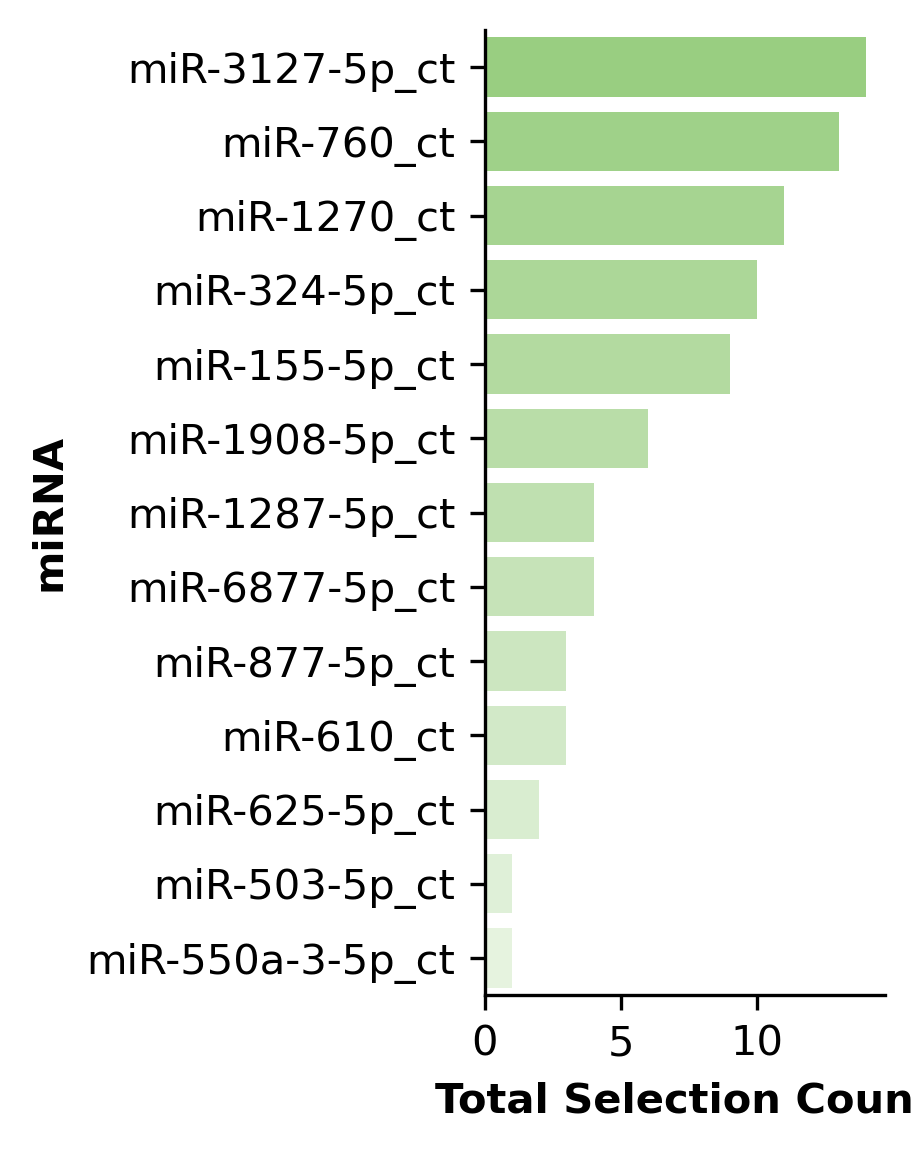

In [232]:
displaying_results(all_subset_averages_ct, n_results = 5, minimum_select_frequency = 15, sorting_metric = 'best_spec', biomarker_lengths = [1, 2, 3], save = True, save_location = r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/top_miRNAs_ct.svg')

1
1
2


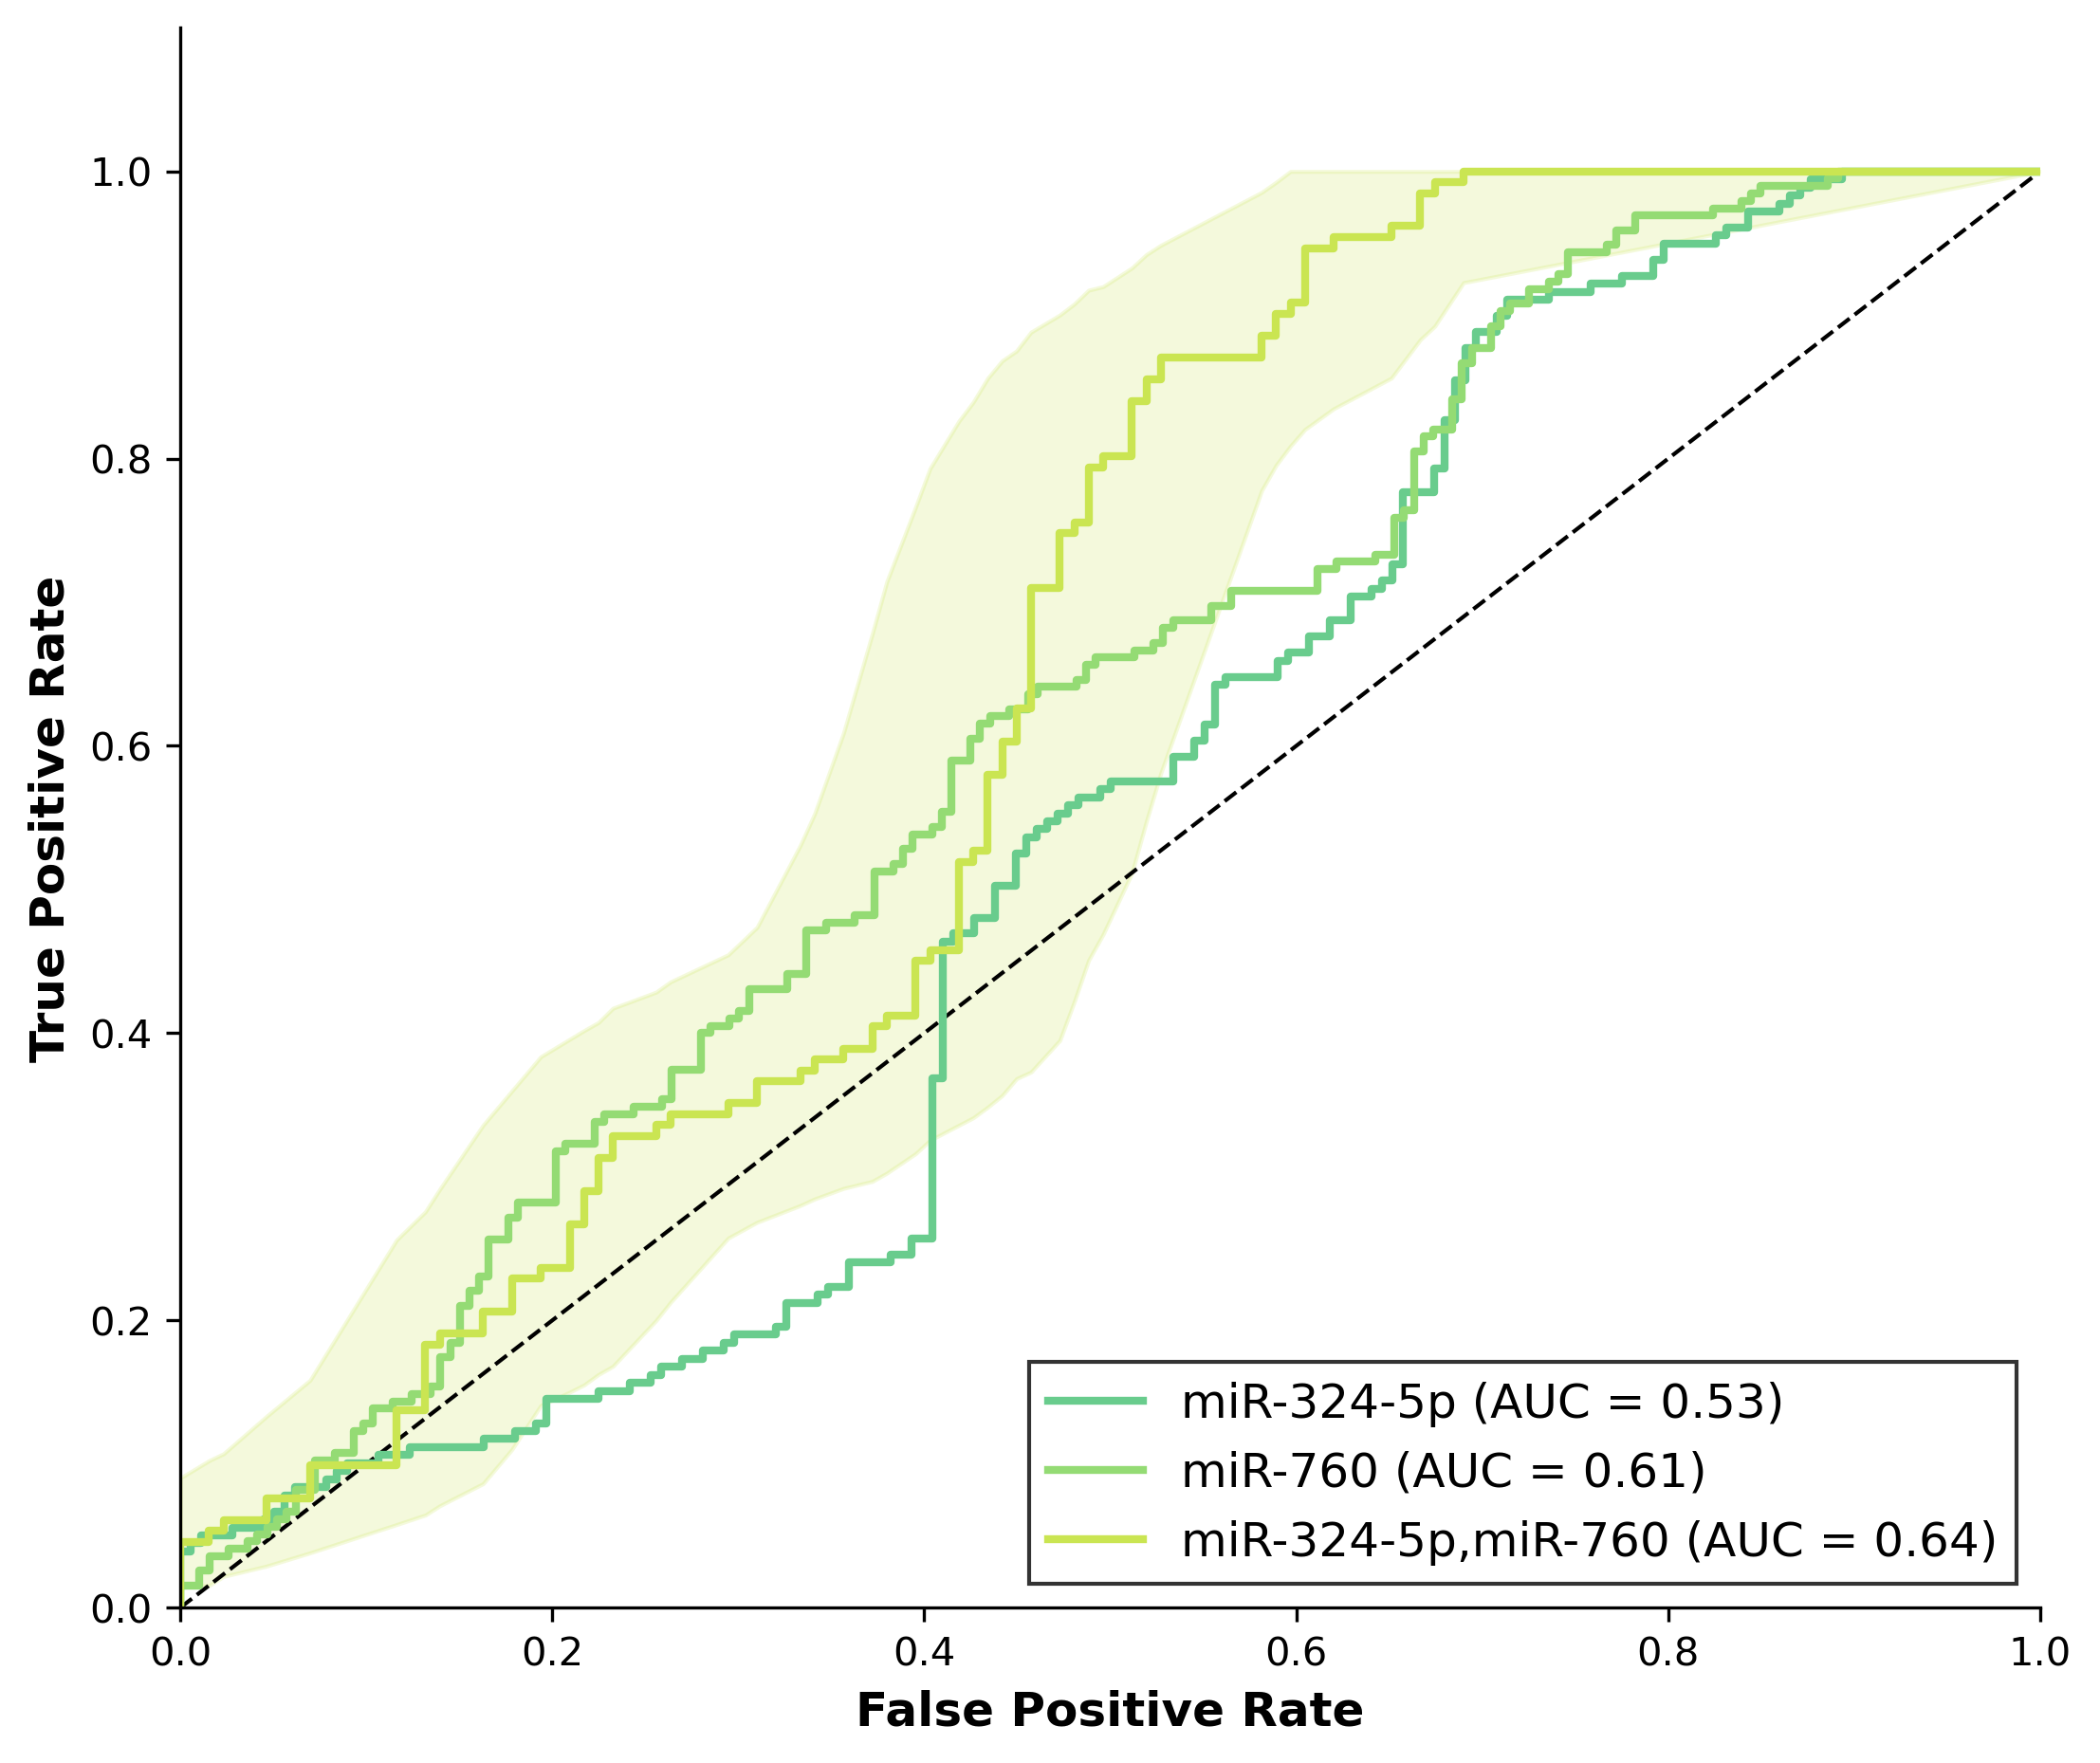

['fn_per_case_per_fold_hsa-miR-324-5p_ct', 'fn_per_case_per_fold_hsa-miR-760_ct', 'fn_per_case_per_fold_hsa-miR-324-5p_ct,hsa-miR-760_ct']
{'fn_per_case_per_fold_hsa-miR-324-5p_ct': 'miR-324-5p', 'fn_per_case_per_fold_hsa-miR-760_ct': 'miR-760', 'fn_per_case_per_fold_hsa-miR-324-5p_ct,hsa-miR-760_ct': 'miR-324-5p + miR-760'}


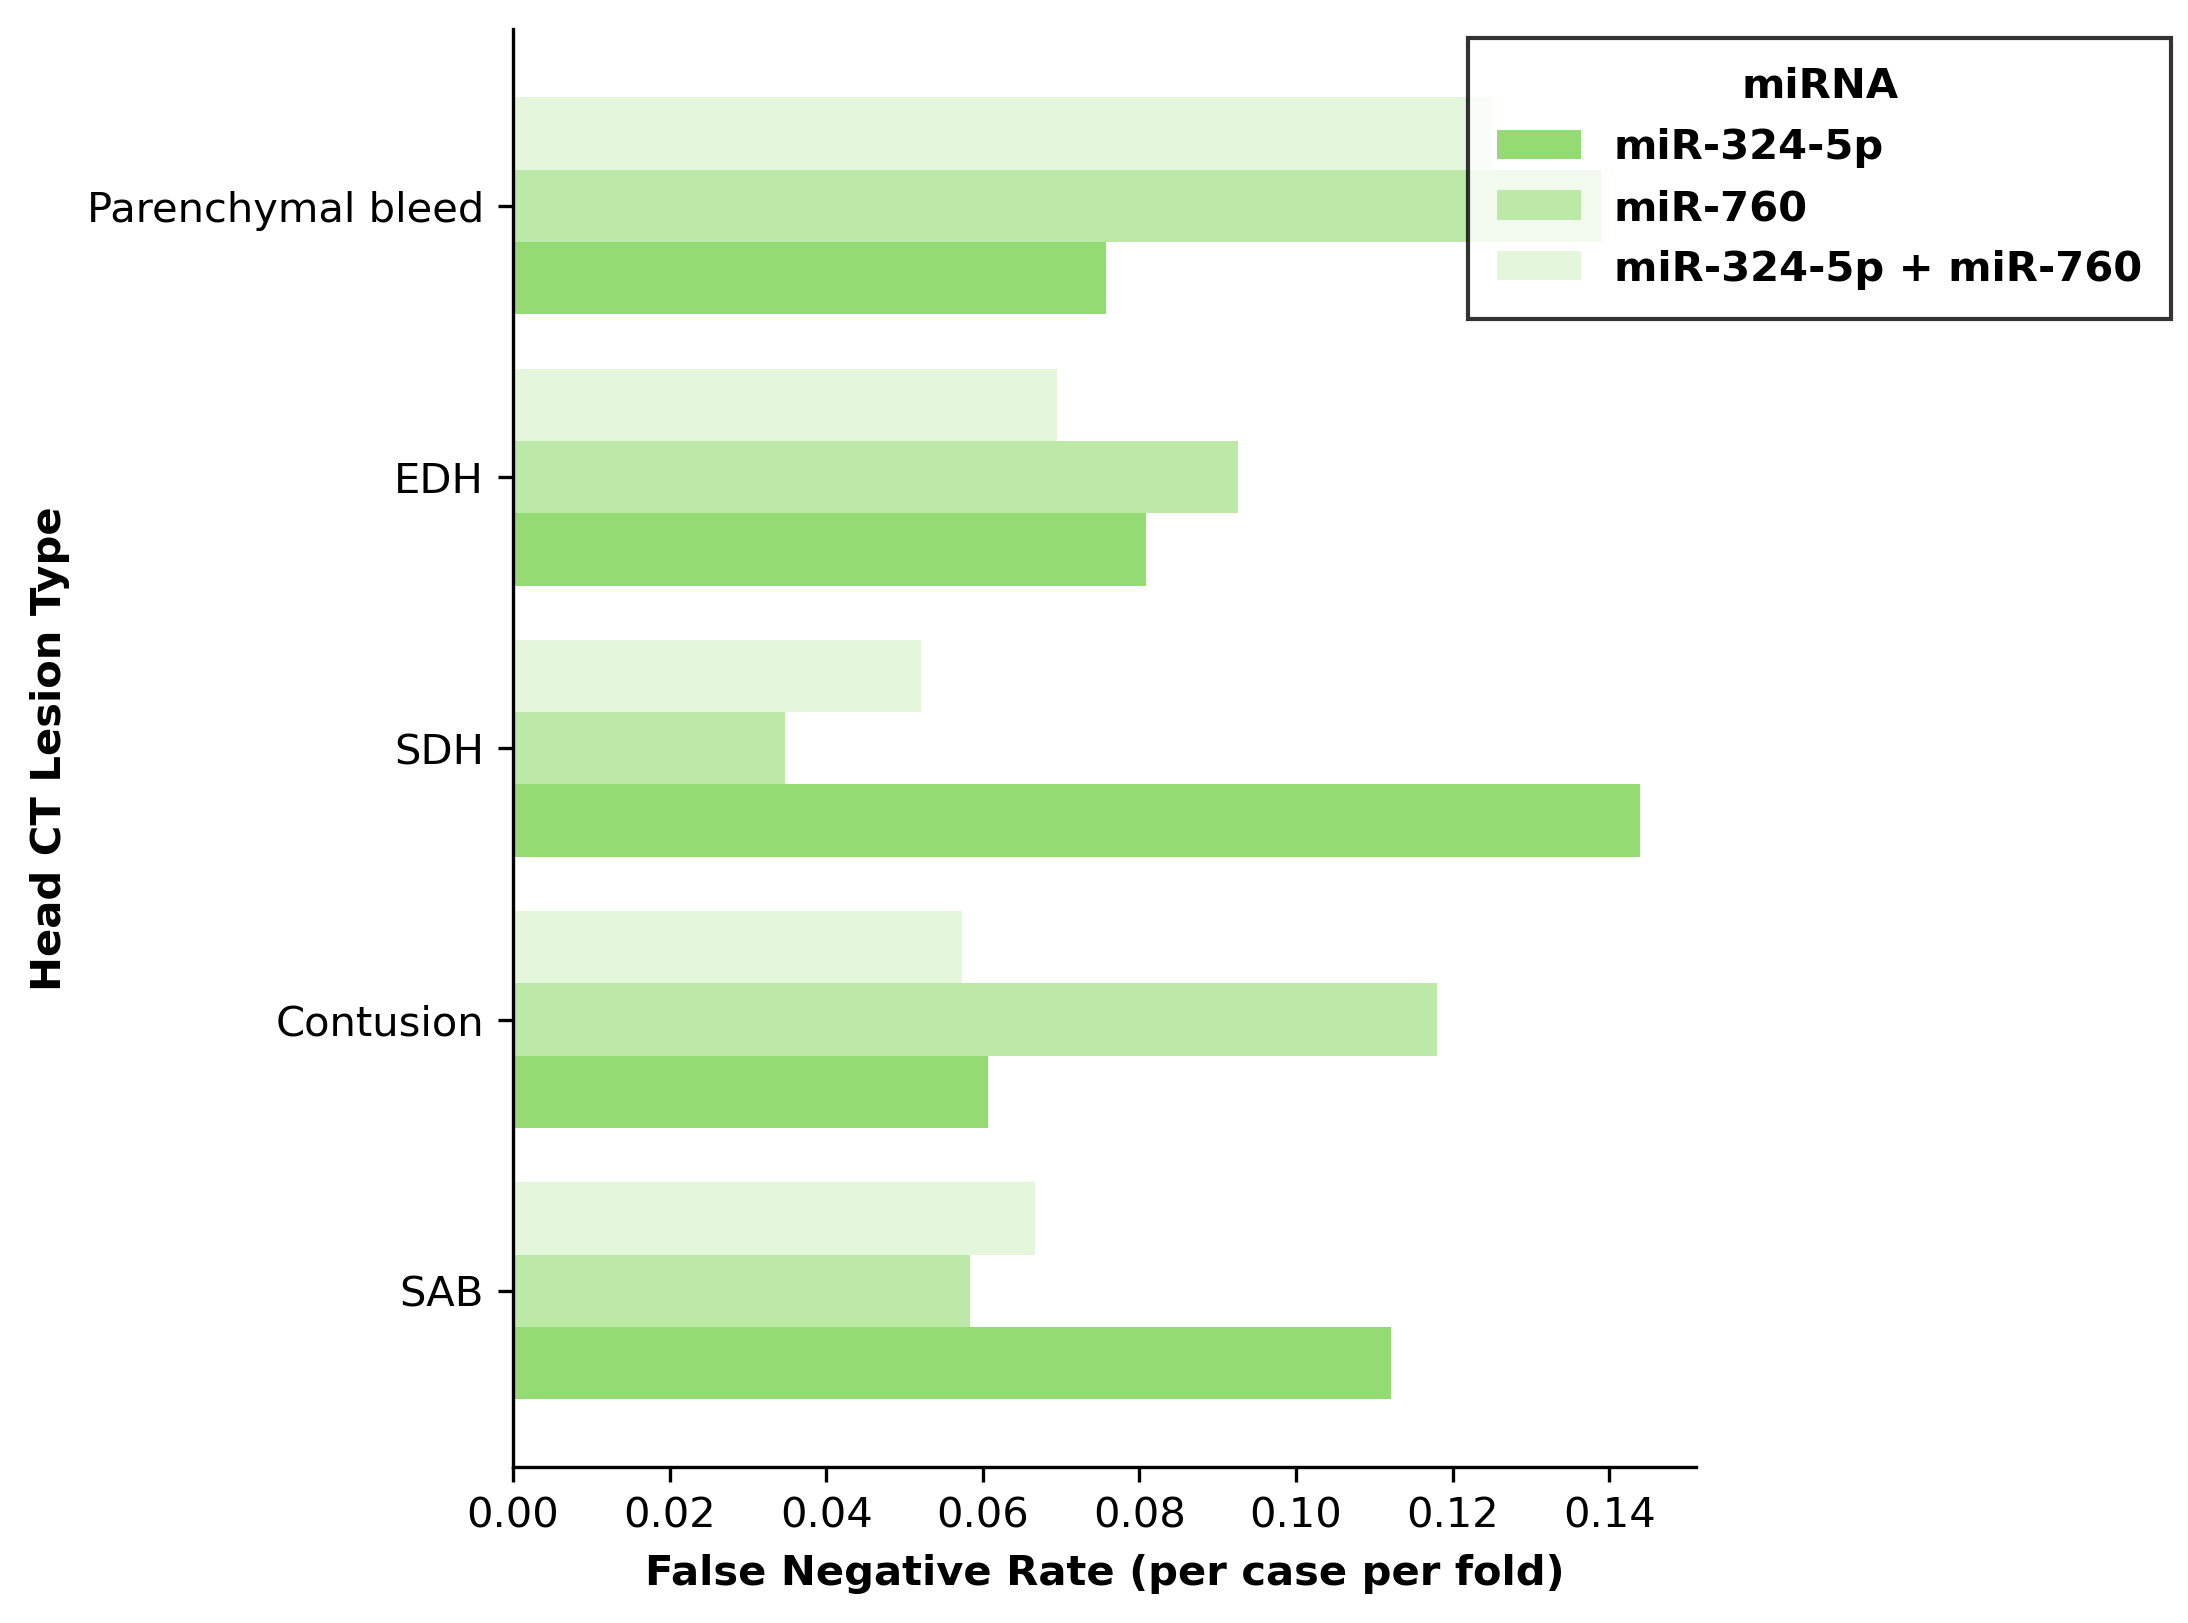

In [204]:
plotter(dataframe = ct_data,
        subset_results = individual_subset_results_ct,
        biomarker_key = 'hsa-miR-324-5p_ct,hsa-miR-760_ct',
        dependent_variable = {'dv': 'ct_abnormalities',
                              'dv_1': 1, 
                              'dv_2': 0, 
                              'dv_1_name': 'CT+', 
                              'dv_2_name': 'CT-'
                              },
        plots = ['roc_aggregated', 'barplot'],
        plot_details = {'roc_aggregated': 
                        {'figsize': [190, 160], 
                         'save': True, 
                         'save_location': r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/roc_aggregated_ct.svg'},
                         'barplot': 
                         {'figsize': [180, 140], 
                          'save': True, 
                          'save_location': r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/barplot_ensemble_ct.svg'}}
        )

<h4>Visualizing Biomarkers</h4>

(<Figure size 3070.87x2125.98 with 5 Axes>,
 [<Axes: title={'center': 'miR-3127-5p'}, ylabel=' RC RNA-Seq (TMM normalized)'>,
  <Axes: title={'center': 'miR-760'}, ylabel=' RC RNA-Seq (TMM normalized)'>,
  <Axes: title={'center': 'miR-1270'}, ylabel=' RC RNA-Seq (TMM normalized)'>,
  <Axes: title={'center': 'miR-324-5p'}, ylabel=' RC RNA-Seq (TMM normalized)'>,
  <Axes: title={'center': 'miR-155-5p'}, ylabel=' RC RNA-Seq (TMM normalized)'>])

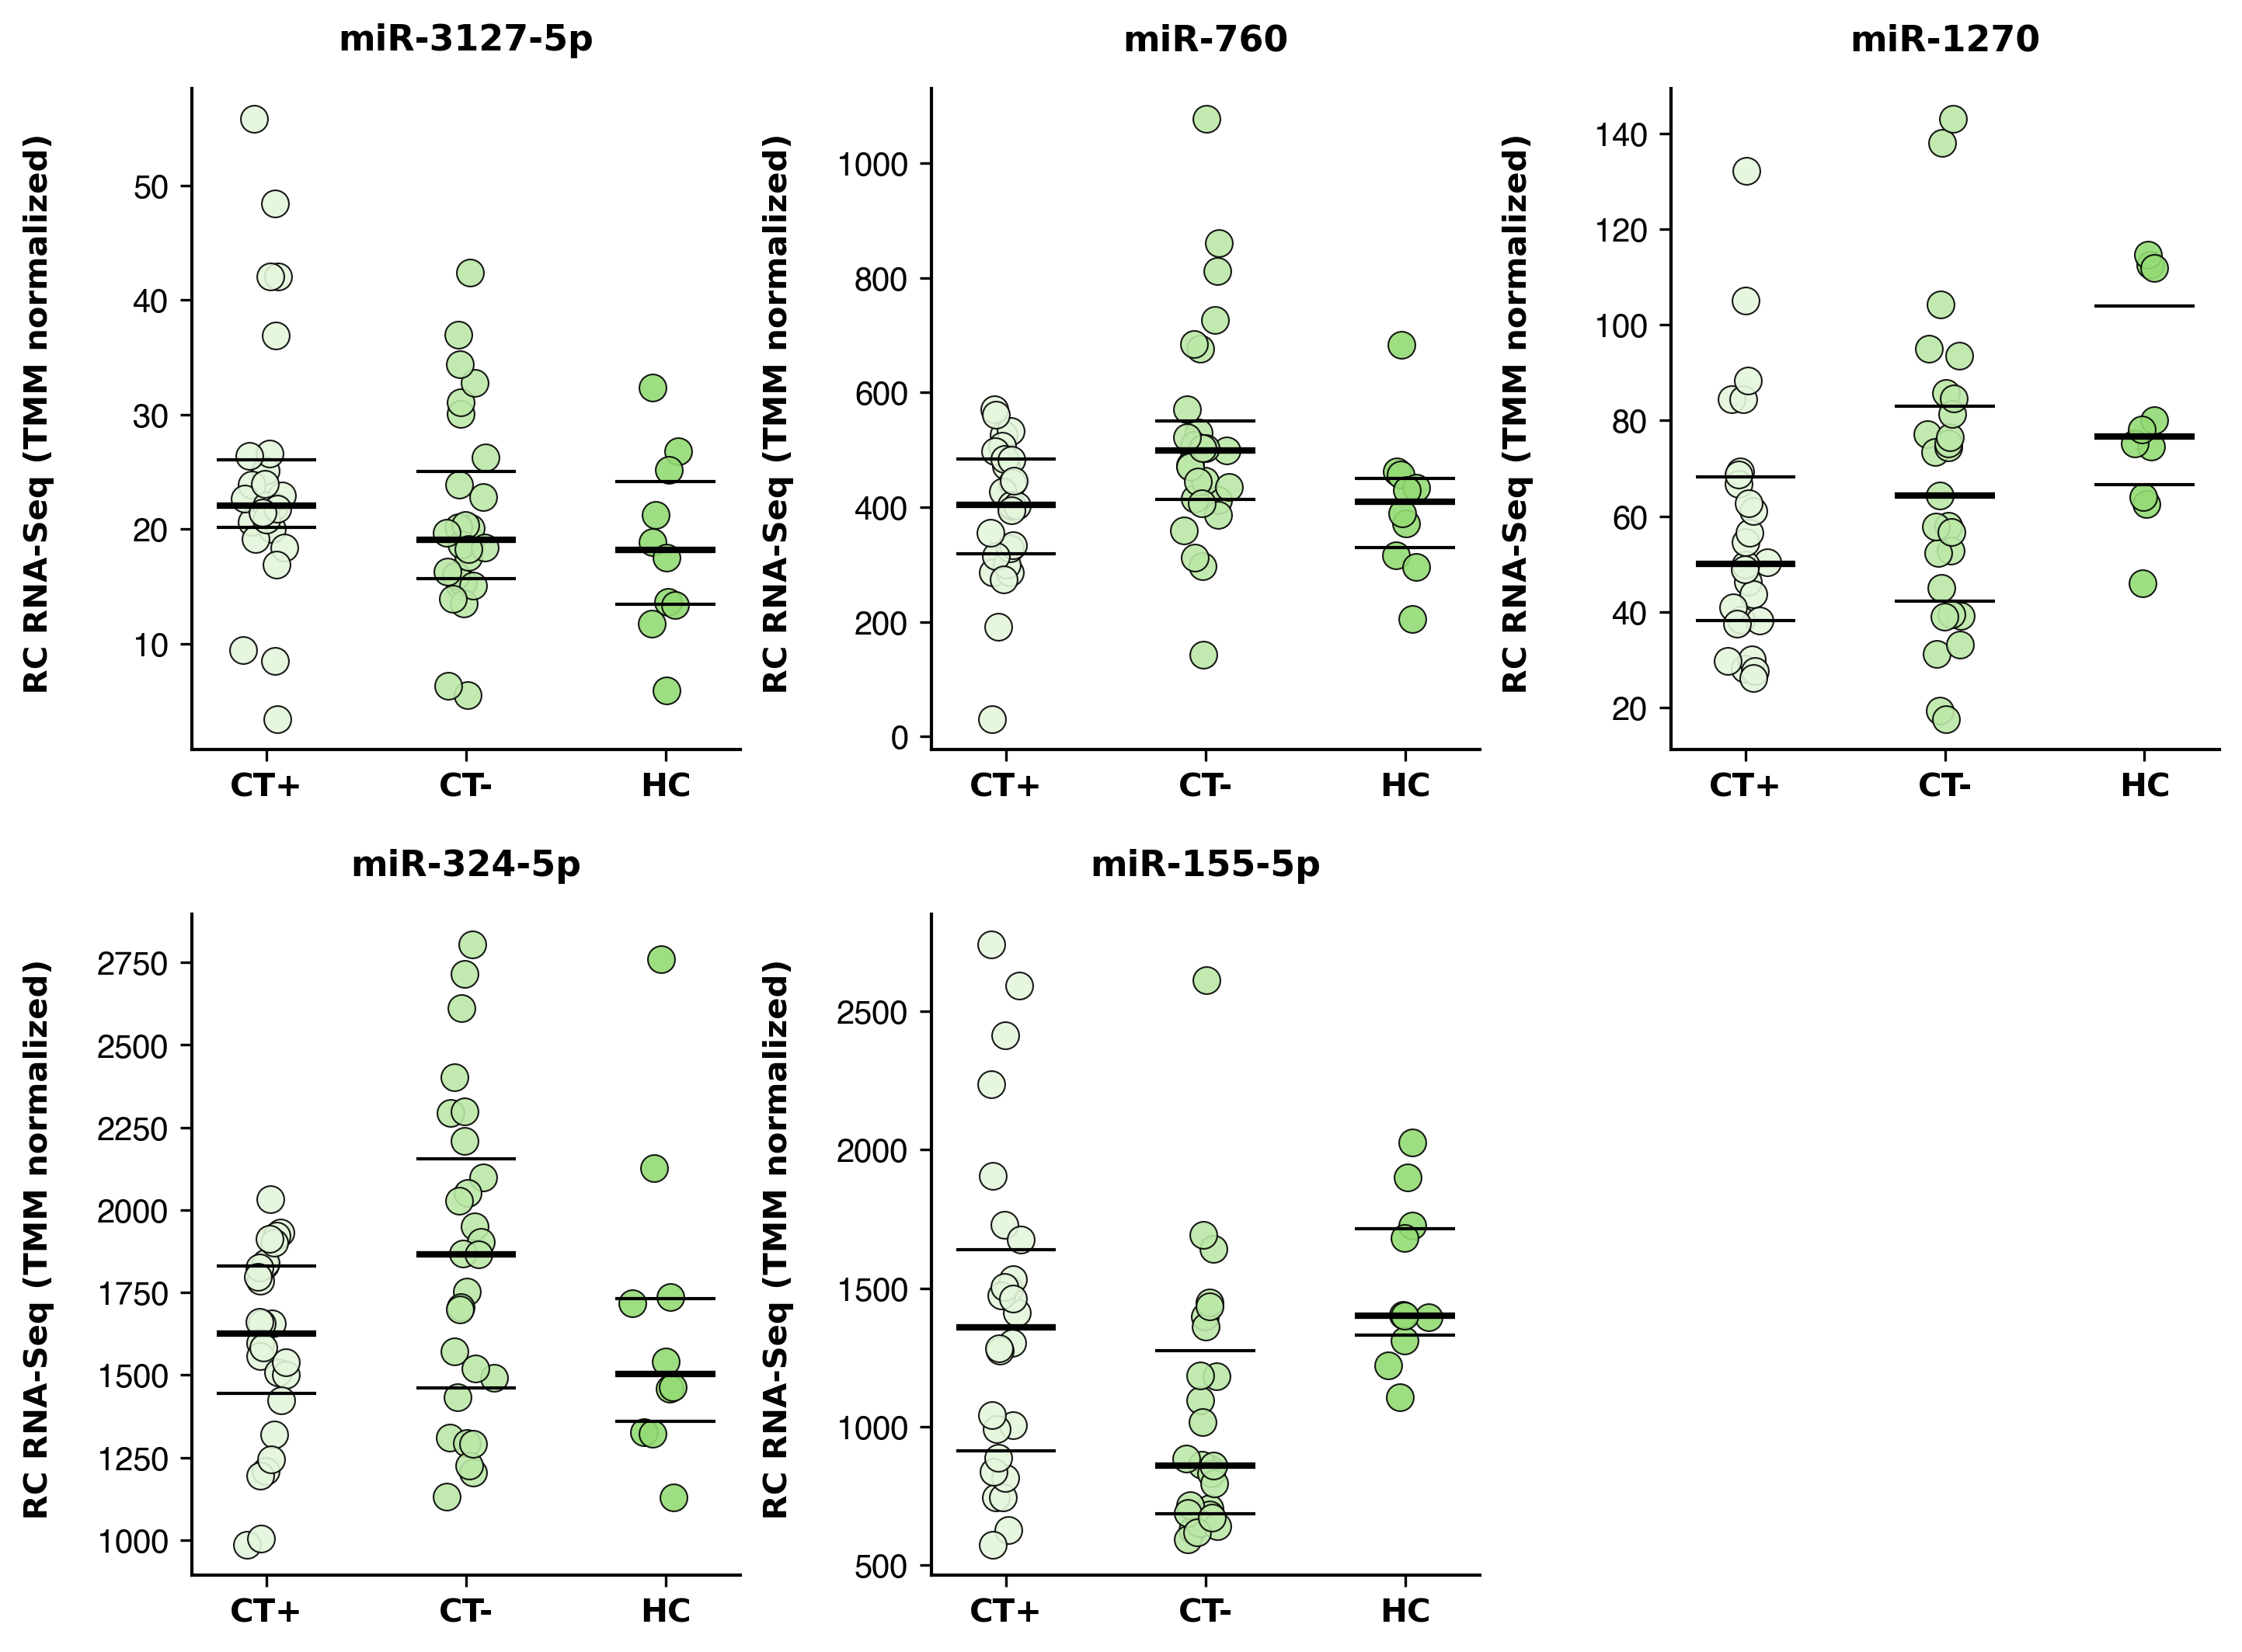

In [159]:
ct_neg = data.iloc[0:64, :].loc[(data['group'] == 1) & (data['ct_abnormalities'] == 0) & (data['sample_id_ct'] !=5)]
ct_pos = data.iloc[0:64, :].loc[(data['group'] == 1) & (data['ct_abnormalities'] == 1) & (data['sample_id_ct'] !=5)]
hc = data.iloc[0:64, :].loc[data['group'] == 0]
margin_dict = {'left': 0.1, 'right': 0.05, 'top': 0.05, 'bottom': 0.05, 'h_spacing': 0.08, 'v_spacing': 0.1}

plot_boxplot(df1 = ct_pos, 
             df2 = ct_neg, 
             df3 = hc, 
             biomarkers = ['hsa-miR-3127-5p_dx', 'hsa-miR-760_dx', 'hsa-miR-1270_dx', 'hsa-miR-324-5p_dx', 'hsa-miR-155-5p_dx'], 
             group_1_name = 'CT+', 
             group_2_name = 'CT-', 
             group_3_name = 'HC', 
             break_thresholds = None, 
             margin_dict = margin_dict,
             colors = None, 
             figsize = (260, 180), 
             figsize_unit = 'mm', 
             dpi=300, 
             save=True,
             save_location = r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/boxplot_ensemble_ct.svg'
             )

<h4>Correlation analysis</h4>

Bbox(x0=0.125, y0=0.13913265306122446, x1=0.9, y1=0.8508673469387755)
{'combination': ['hsa-miR-3127-5p_ct-age', 'hsa-miR-760_ct-age', 'hsa-miR-1270_ct-age', 'hsa-miR-324-5p_ct-age', 'hsa-miR-155-5p_ct-age', 'hsa-miR-3127-5p_ct-gender', 'hsa-miR-760_ct-gender', 'hsa-miR-1270_ct-gender', 'hsa-miR-324-5p_ct-gender', 'hsa-miR-155-5p_ct-gender', 'hsa-miR-3127-5p_ct-extracranial_dicho', 'hsa-miR-760_ct-extracranial_dicho', 'hsa-miR-1270_ct-extracranial_dicho', 'hsa-miR-324-5p_ct-extracranial_dicho', 'hsa-miR-155-5p_ct-extracranial_dicho', 'hsa-miR-3127-5p_ct-pta_dicho', 'hsa-miR-760_ct-pta_dicho', 'hsa-miR-1270_ct-pta_dicho', 'hsa-miR-324-5p_ct-pta_dicho', 'hsa-miR-155-5p_ct-pta_dicho', 'hsa-miR-3127-5p_ct-loc_dicho', 'hsa-miR-760_ct-loc_dicho', 'hsa-miR-1270_ct-loc_dicho', 'hsa-miR-324-5p_ct-loc_dicho', 'hsa-miR-155-5p_ct-loc_dicho', 'hsa-miR-3127-5p_ct-time_to_v1_minutes', 'hsa-miR-760_ct-time_to_v1_minutes', 'hsa-miR-1270_ct-time_to_v1_minutes', 'hsa-miR-324-5p_ct-time_to_v1_minutes', 'h

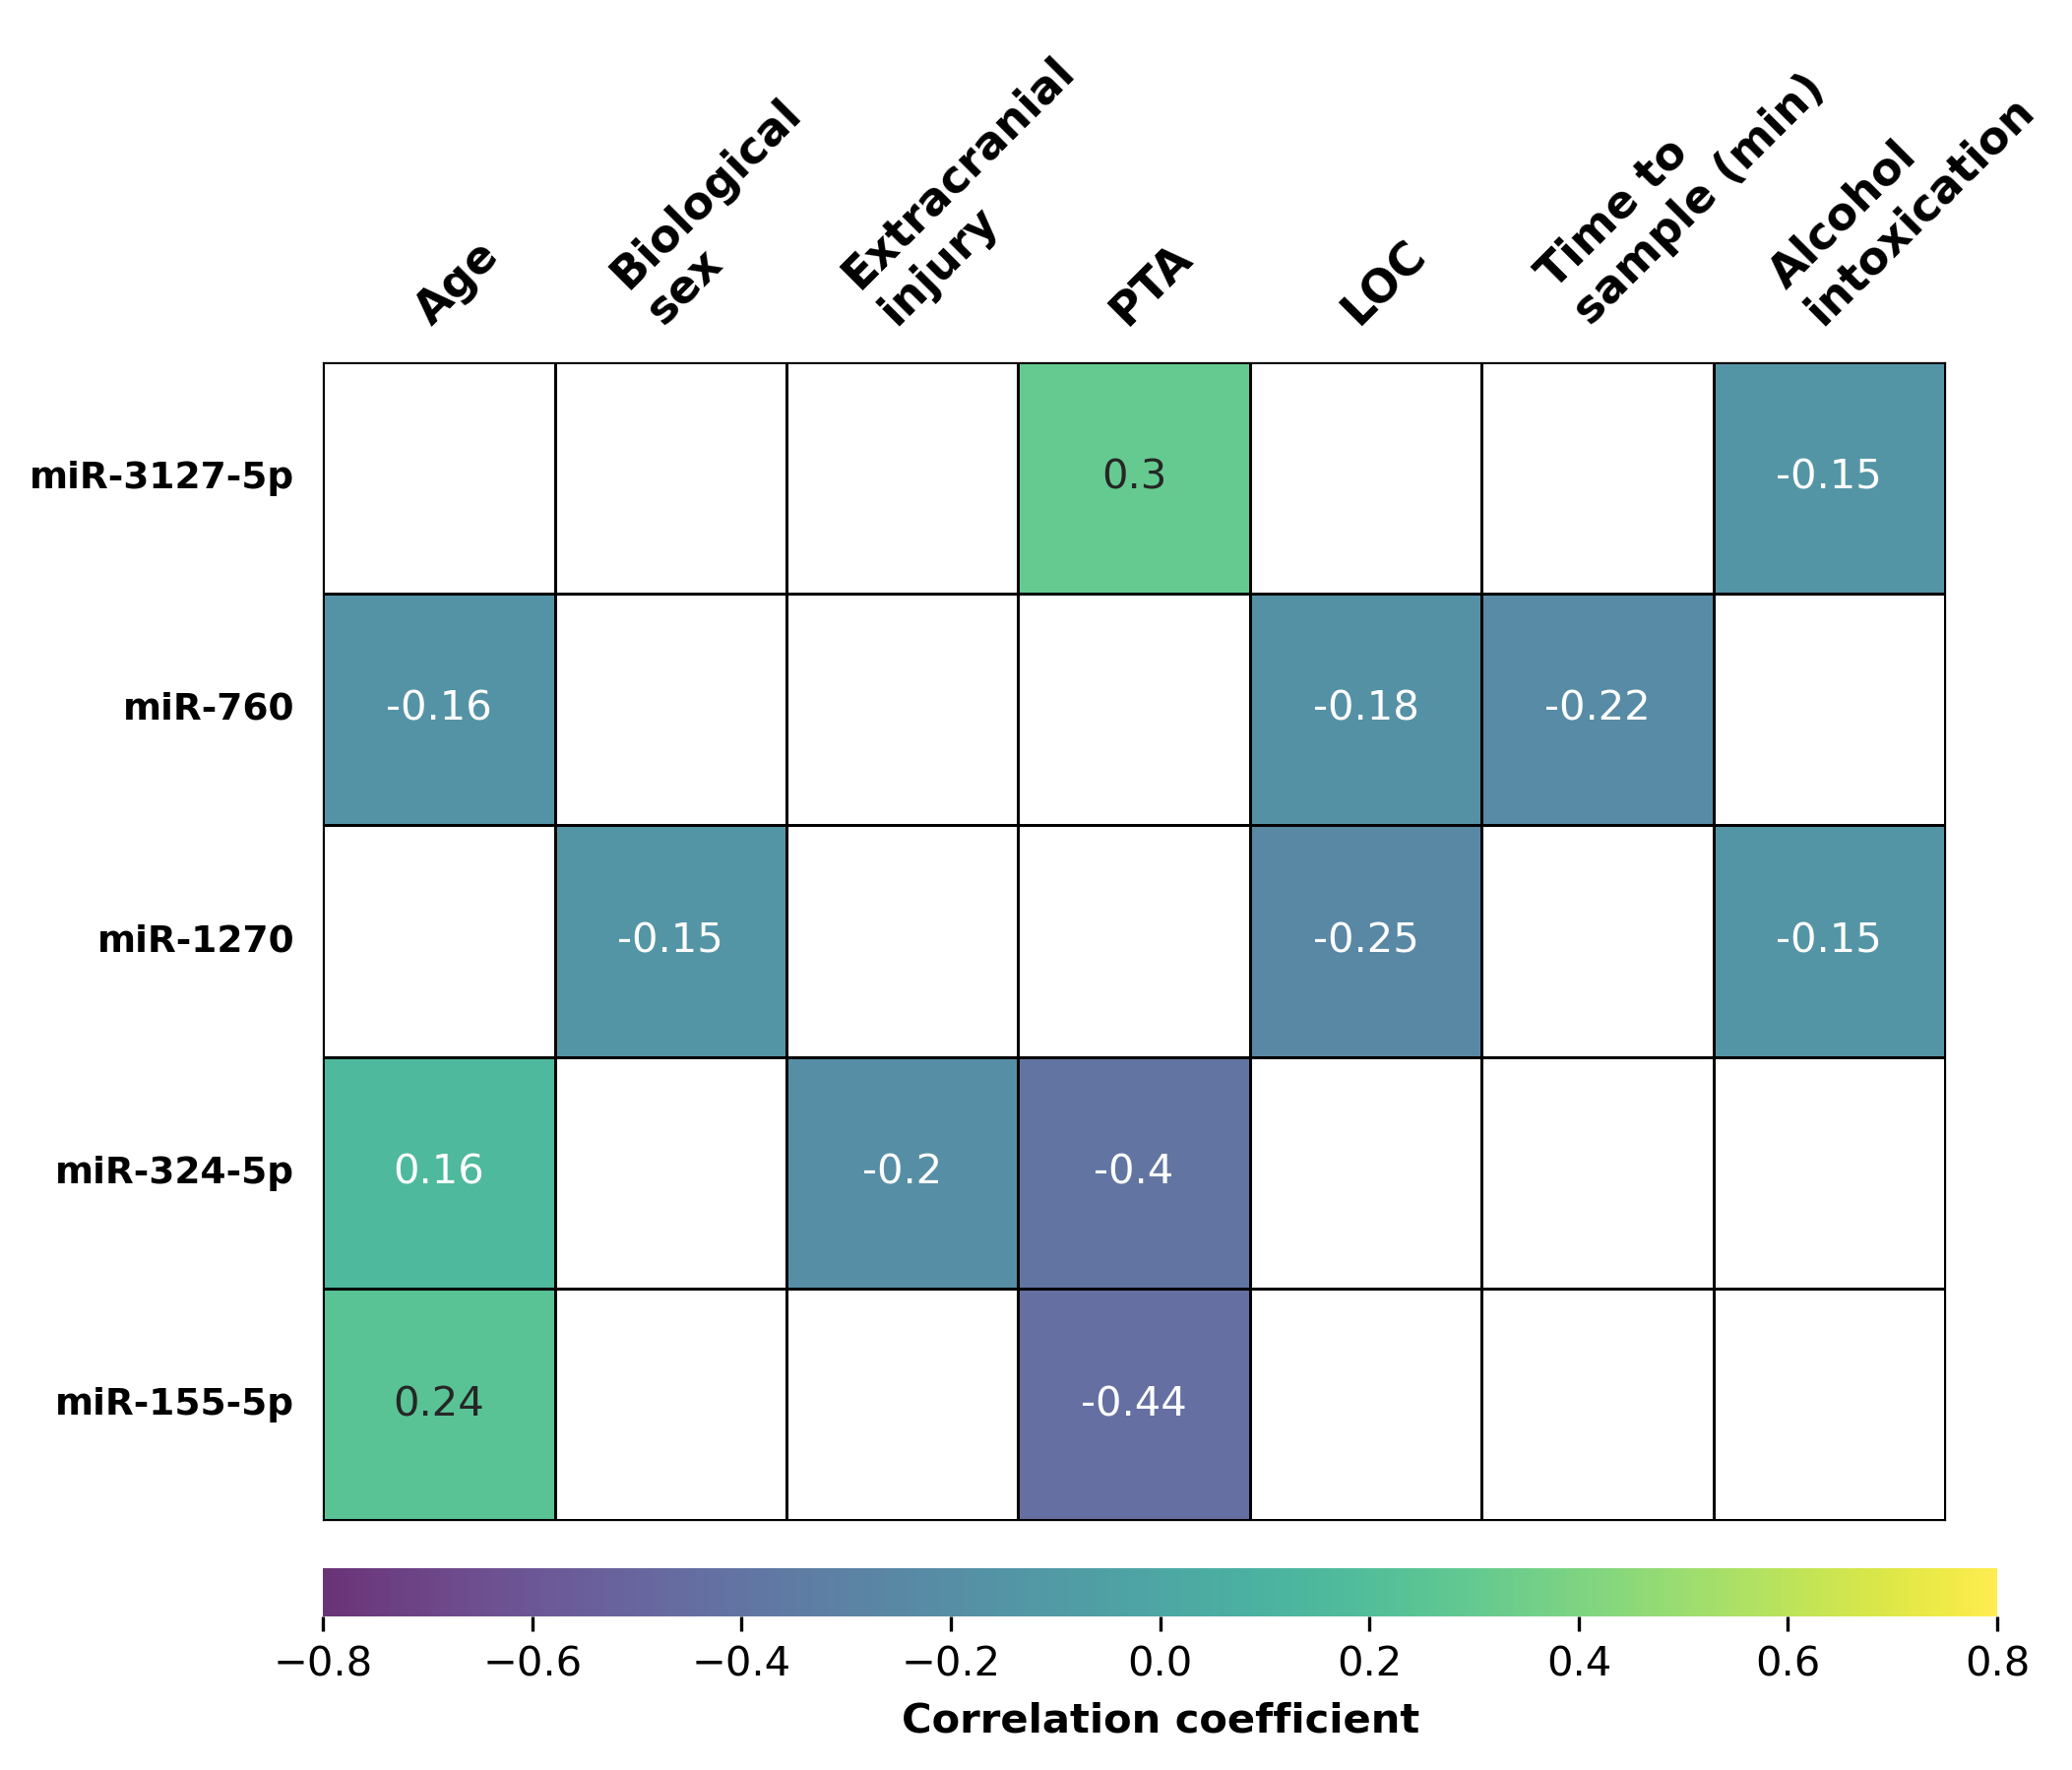

In [234]:
exploratory_variables = {'age':1, 'gender':2, 'extracranial_dicho': 2, 'pta_dicho': 2, 'loc_dicho': 2, 'time_to_v1_minutes':1, 'alcohol_intoxication': 2}
mirna = {'hsa-miR-3127-5p_ct': 0, 'hsa-miR-760_ct': 0, 'hsa-miR-1270_ct': 0, 'hsa-miR-324-5p_ct': 0, 'hsa-miR-155-5p_ct': 0}
ytick_labels = ['miR-3127-5p', 'miR-760', 'miR-1270', 'miR-324-5p', 'miR-155-5p']
xtick_labels = ['Age', 'Biological\nsex', 'Extracranial\ninjury', 'PTA', 'LOC', 'Time to\nsample (min)', 'Alcohol\nintoxication']
p_list = makeHeatmap(ct_data, exploratory_variables, mirna, xtick_labels, ytick_labels, spec=True, saveFig=False, name=r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/corr_analysis_ct.svg', covar=[], covar_variables=[], figsize=[180, 140])
print(p_list)

<h3>Evaluating GOSE</h3>

In [182]:
gose_data = data.iloc[0:64, :].loc[(data['group'] == 1) & (data['gose_dichotimized'] != 99) & (data['sample_id_ct'] !=5)]
gose_start_col_index = data.columns.get_loc('hsa-miR-671-5p_gose')
gose_end_col_index = data.columns.get_loc('hsa-miR-183-3p_gose')

gose_results_pickle = 'mirna_gose_results.pkl'

with open(gose_results_pickle, "rb") as f:
    results_gose = pickle.load(f)

    all_subset_averages_gose, individual_subset_results_gose = nested_ensemble_feature_selection_plus_evaluation(
    dataframe = gose_data,
    start_index_mirna = gose_start_col_index,
    end_index_mirna = gose_end_col_index,
    dv = 'gose_dichotimized',
    n_iterations = 500,
    max_features = 10,
    evaluation = True,
    results = results_gose,
    pickle_name = gose_results_pickle,
    )

/Users/koen_phd/miniforge3/envs/tf/lib/python3.8/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/koen_phd/miniforge3/envs/tf/lib/python3.8/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Results for subsets of 1 biomarkers:
 number of unique subsets: 76


,coefficients,AUC,Specificity,Sensitivity,Youden Index,Nagelkerke R2,best_spec,best_sens@_best_spec,best_threshold@_best_spec,times_selected
hsa-miR-330-3p_gose,"{'hsa-miR-330-3p_gose': {'mean': 0.8548, '95% ...","(0.717, (0.673, 0.761))","(0.533, (0.467, 0.599))","(0.701, (0.651, 0.751))","(0.235, (0.158, 0.312))","(0.118, (0.059, 0.176))","(0.379, (0.318, 0.441))","(1.0, (1.0, 1.0))","(0.358, (0.321, 0.395))",48
hsa-miR-3127-5p_gose,"{'hsa-miR-3127-5p_gose': {'mean': -0.8241, '95...","(0.691, (0.644, 0.738))","(0.468, (0.401, 0.536))","(0.755, (0.703, 0.807))","(0.224, (0.148, 0.299))","(0.061, (0.011, 0.111))","(0.289, (0.209, 0.37))","(1.0, (1.0, 1.0))","(0.341, (0.298, 0.384))",38
hsa-miR-301a-3p_gose,"{'hsa-miR-301a-3p_gose': {'mean': 0.8514, '95%...","(0.668, (0.621, 0.715))","(0.533, (0.461, 0.606))","(0.535, (0.451, 0.618))","(0.068, (-0.004, 0.14))","(0.002, (-0.067, 0.071))","(0.341, (0.265, 0.416))","(1.0, (1.0, 1.0))","(0.352, (0.323, 0.381))",27
hsa-miR-197-5p_gose,"{'hsa-miR-197-5p_gose': {'mean': -0.8126, '95%...","(0.663, (0.597, 0.728))","(0.469, (0.381, 0.558))","(0.758, (0.687, 0.828))","(0.227, (0.139, 0.315))","(-0.021, (-0.15, 0.108))","(0.292, (0.178, 0.407))","(1.0, (1.0, 1.0))","(0.351, (0.283, 0.42))",26
hsa-miR-11400_gose,"{'hsa-miR-11400_gose': {'mean': 0.9202, '95% C...","(0.655, (0.595, 0.715))","(0.624, (0.537, 0.711))","(0.659, (0.553, 0.764))","(0.283, (0.159, 0.406))","(0.036, (-0.063, 0.136))","(0.312, (0.193, 0.431))","(1.0, (1.0, 1.0))","(0.372, (0.324, 0.42))",25


{'hsa-miR-330-3p_gose': {'mean': 0.8548, '95% CI': (0.8144, 0.8953)}}
{'hsa-miR-3127-5p_gose': {'mean': -0.8241, '95% CI': (-0.8643, -0.784)}}
{'hsa-miR-301a-3p_gose': {'mean': 0.8514, '95% CI': (0.8082, 0.8945)}}
{'hsa-miR-197-5p_gose': {'mean': -0.8126, '95% CI': (-0.8863, -0.7389)}}
{'hsa-miR-11400_gose': {'mean': 0.9202, '95% CI': (0.8321, 1.0083)}}
Results for subsets of 2 biomarkers:
 number of unique subsets: 879


,coefficients,AUC,Specificity,Sensitivity,Youden Index,Nagelkerke R2,best_spec,best_sens@_best_spec,best_threshold@_best_spec,times_selected
"hsa-miR-3127-5p_gose,hsa-miR-330-3p_gose","{'hsa-miR-3127-5p_gose': {'mean': -0.6167, '95...","(0.758, (0.714, 0.801))","(0.572, (0.505, 0.639))","(0.776, (0.72, 0.832))","(0.348, (0.259, 0.438))","(0.12, (0.027, 0.213))","(0.389, (0.292, 0.486))","(1.0, (1.0, 1.0))","(0.323, (0.259, 0.388))",36
"hsa-miR-128-3p_gose,hsa-miR-330-3p_gose","{'hsa-miR-330-3p_gose': {'mean': 0.8026, '95% ...","(0.73, (0.676, 0.783))","(0.504, (0.397, 0.611))","(0.741, (0.657, 0.824))","(0.245, (0.121, 0.368))","(0.139, (0.068, 0.211))","(0.383, (0.293, 0.473))","(1.0, (1.0, 1.0))","(0.374, (0.319, 0.429))",23
"hsa-miR-11400_gose,hsa-miR-330-3p_gose","{'hsa-miR-330-3p_gose': {'mean': 0.7045, '95% ...","(0.717, (0.652, 0.783))","(0.584, (0.489, 0.679))","(0.731, (0.645, 0.817))","(0.315, (0.194, 0.436))","(0.062, (-0.091, 0.214))","(0.392, (0.29, 0.494))","(1.0, (1.0, 1.0))","(0.351, (0.274, 0.427))",25
"hsa-miR-197-5p_gose,hsa-miR-330-3p_gose","{'hsa-miR-197-5p_gose': {'mean': -0.5528, '95%...","(0.713, (0.647, 0.778))","(0.538, (0.454, 0.623))","(0.801, (0.729, 0.874))","(0.34, (0.237, 0.442))","(0.026, (-0.125, 0.177))","(0.385, (0.266, 0.503))","(1.0, (1.0, 1.0))","(0.354, (0.272, 0.436))",26
"hsa-miR-197-5p_gose,hsa-miR-3127-5p_gose","{'hsa-miR-197-5p_gose': {'mean': -0.5624, '95%...","(0.71, (0.639, 0.781))","(0.6, (0.521, 0.679))","(0.739, (0.651, 0.827))","(0.339, (0.213, 0.464))","(0.011, (-0.14, 0.163))","(0.316, (0.167, 0.464))","(1.0, (1.0, 1.0))","(0.29, (0.201, 0.378))",19


{'hsa-miR-3127-5p_gose': {'mean': -0.6167, '95% CI': (-0.6636, -0.5697)}, 'hsa-miR-330-3p_gose': {'mean': 0.6782, '95% CI': (0.6307, 0.7257)}}
{'hsa-miR-330-3p_gose': {'mean': 0.8026, '95% CI': (0.7452, 0.8599)}, 'hsa-miR-128-3p_gose': {'mean': 0.7718, '95% CI': (0.6912, 0.8523)}}
{'hsa-miR-330-3p_gose': {'mean': 0.7045, '95% CI': (0.6483, 0.7607)}, 'hsa-miR-11400_gose': {'mean': 0.5529, '95% CI': (0.4788, 0.6271)}}
{'hsa-miR-197-5p_gose': {'mean': -0.5528, '95% CI': (-0.6355, -0.4701)}, 'hsa-miR-330-3p_gose': {'mean': 0.6514, '95% CI': (0.6011, 0.7017)}}
{'hsa-miR-197-5p_gose': {'mean': -0.5624, '95% CI': (-0.6548, -0.47)}, 'hsa-miR-3127-5p_gose': {'mean': -0.5792, '95% CI': (-0.6399, -0.5184)}}
Results for subsets of 3 biomarkers:
 number of unique subsets: 3817


,coefficients,AUC,Specificity,Sensitivity,Youden Index,Nagelkerke R2,best_spec,best_sens@_best_spec,best_threshold@_best_spec,times_selected
"hsa-miR-11400_gose,hsa-miR-3127-5p_gose,hsa-miR-330-3p_gose","{'hsa-miR-3127-5p_gose': {'mean': -0.5199, '95...","(0.771, (0.714, 0.828))","(0.529, (0.449, 0.61))","(0.771, (0.669, 0.872))","(0.3, (0.191, 0.409))","(0.088, (-0.106, 0.282))","(0.376, (0.227, 0.526))","(1.0, (1.0, 1.0))","(0.334, (0.222, 0.446))",17
"hsa-miR-128-3p_gose,hsa-miR-3127-5p_gose,hsa-miR-330-3p_gose","{'hsa-miR-3127-5p_gose': {'mean': -0.5322, '95...","(0.768, (0.71, 0.826))","(0.526, (0.434, 0.618))","(0.775, (0.668, 0.883))","(0.302, (0.17, 0.433))","(0.168, (0.08, 0.256))","(0.389, (0.259, 0.52))","(1.0, (1.0, 1.0))","(0.364, (0.278, 0.449))",19
"hsa-miR-197-5p_gose,hsa-miR-3127-5p_gose,hsa-miR-330-3p_gose","{'hsa-miR-197-5p_gose': {'mean': -0.3523, '95%...","(0.738, (0.658, 0.817))","(0.558, (0.449, 0.667))","(0.767, (0.68, 0.853))","(0.325, (0.19, 0.459))","(0.047, (-0.11, 0.203))","(0.368, (0.198, 0.539))","(1.0, (1.0, 1.0))","(0.301, (0.197, 0.406))",19
"hsa-miR-3127-5p_gose,hsa-miR-330-3p_gose,hsa-miR-760_gose","{'hsa-miR-330-3p_gose': {'mean': 0.6478, '95% ...","(0.729, (0.654, 0.805))","(0.671, (0.562, 0.779))","(0.724, (0.654, 0.793))","(0.394, (0.272, 0.516))","(0.078, (-0.06, 0.216))","(0.471, (0.362, 0.579))","(1.0, (1.0, 1.0))","(0.32, (0.255, 0.385))",17
"hsa-miR-1270_gose,hsa-miR-3127-5p_gose,hsa-miR-330-3p_gose","{'hsa-miR-1270_gose': {'mean': 0.6797, '95% CI...","(0.713, (0.63, 0.797))","(0.659, (0.558, 0.76))","(0.759, (0.645, 0.873))","(0.418, (0.244, 0.591))","(-0.177, (-0.52, 0.166))","(0.376, (0.206, 0.547))","(1.0, (1.0, 1.0))","(0.291, (0.172, 0.41))",17


{'hsa-miR-3127-5p_gose': {'mean': -0.5199, '95% CI': (-0.5947, -0.4451)}, 'hsa-miR-330-3p_gose': {'mean': 0.5993, '95% CI': (0.5395, 0.659)}, 'hsa-miR-11400_gose': {'mean': 0.3807, '95% CI': (0.3257, 0.4356)}}
{'hsa-miR-3127-5p_gose': {'mean': -0.5322, '95% CI': (-0.5895, -0.4748)}, 'hsa-miR-330-3p_gose': {'mean': 0.6358, '95% CI': (0.573, 0.6986)}, 'hsa-miR-128-3p_gose': {'mean': 0.6479, '95% CI': (0.5494, 0.7464)}}
{'hsa-miR-197-5p_gose': {'mean': -0.3523, '95% CI': (-0.4513, -0.2533)}, 'hsa-miR-330-3p_gose': {'mean': 0.6016, '95% CI': (0.5439, 0.6592)}, 'hsa-miR-3127-5p_gose': {'mean': -0.4759, '95% CI': (-0.5384, -0.4133)}}
{'hsa-miR-330-3p_gose': {'mean': 0.6478, '95% CI': (0.5609, 0.7347)}, 'hsa-miR-760_gose': {'mean': 0.7046, '95% CI': (0.6274, 0.7818)}, 'hsa-miR-3127-5p_gose': {'mean': -0.894, '95% CI': (-0.9917, -0.7963)}}
{'hsa-miR-1270_gose': {'mean': 0.6797, '95% CI': (0.5505, 0.8088)}, 'hsa-miR-3127-5p_gose': {'mean': -0.7157, '95% CI': (-0.8133, -0.618)}, 'hsa-miR-330-3p_

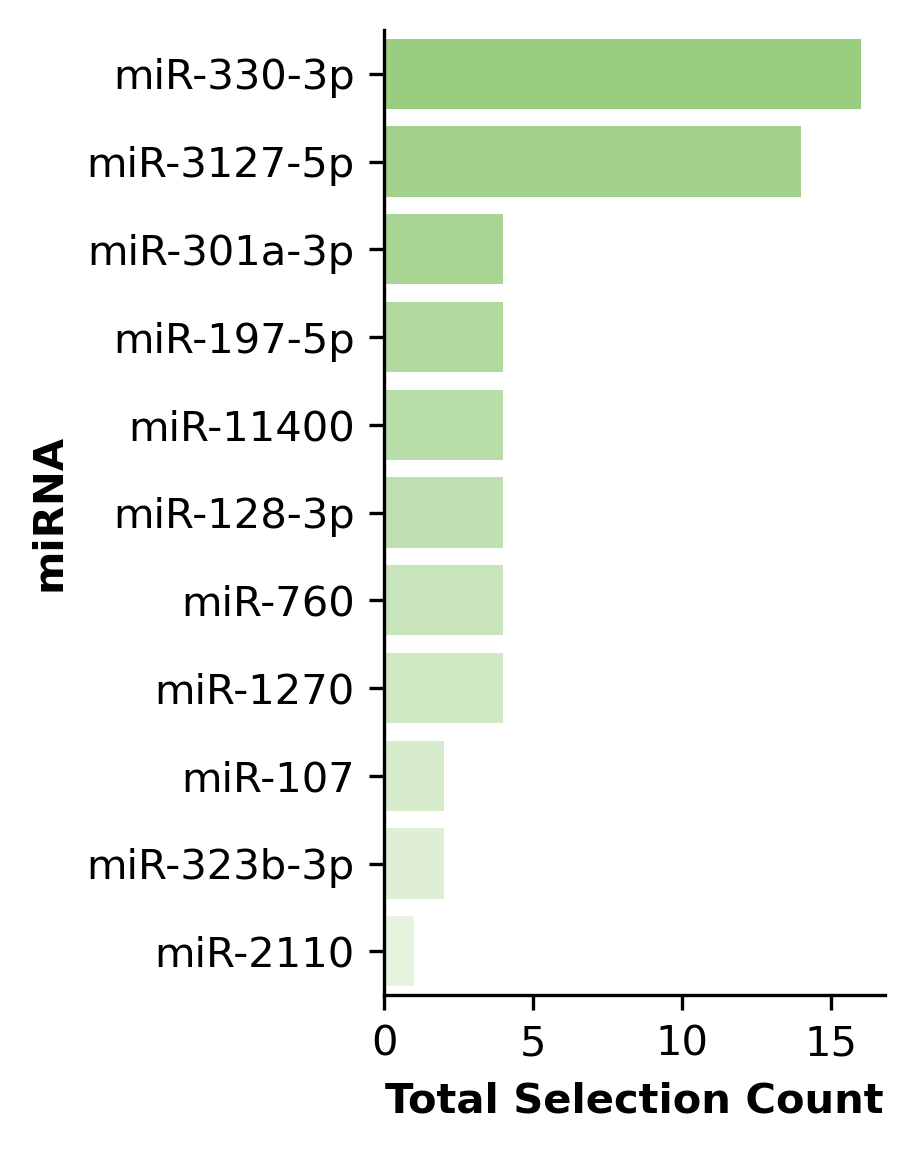

In [207]:
displaying_results(all_subset_averages_gose, n_results = 5, minimum_select_frequency = 15, sorting_metric = 'AUC', biomarker_lengths = [1, 2, 3], save = True, save_location = r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/top_miRNAs_gose.svg')

1
1
1
3


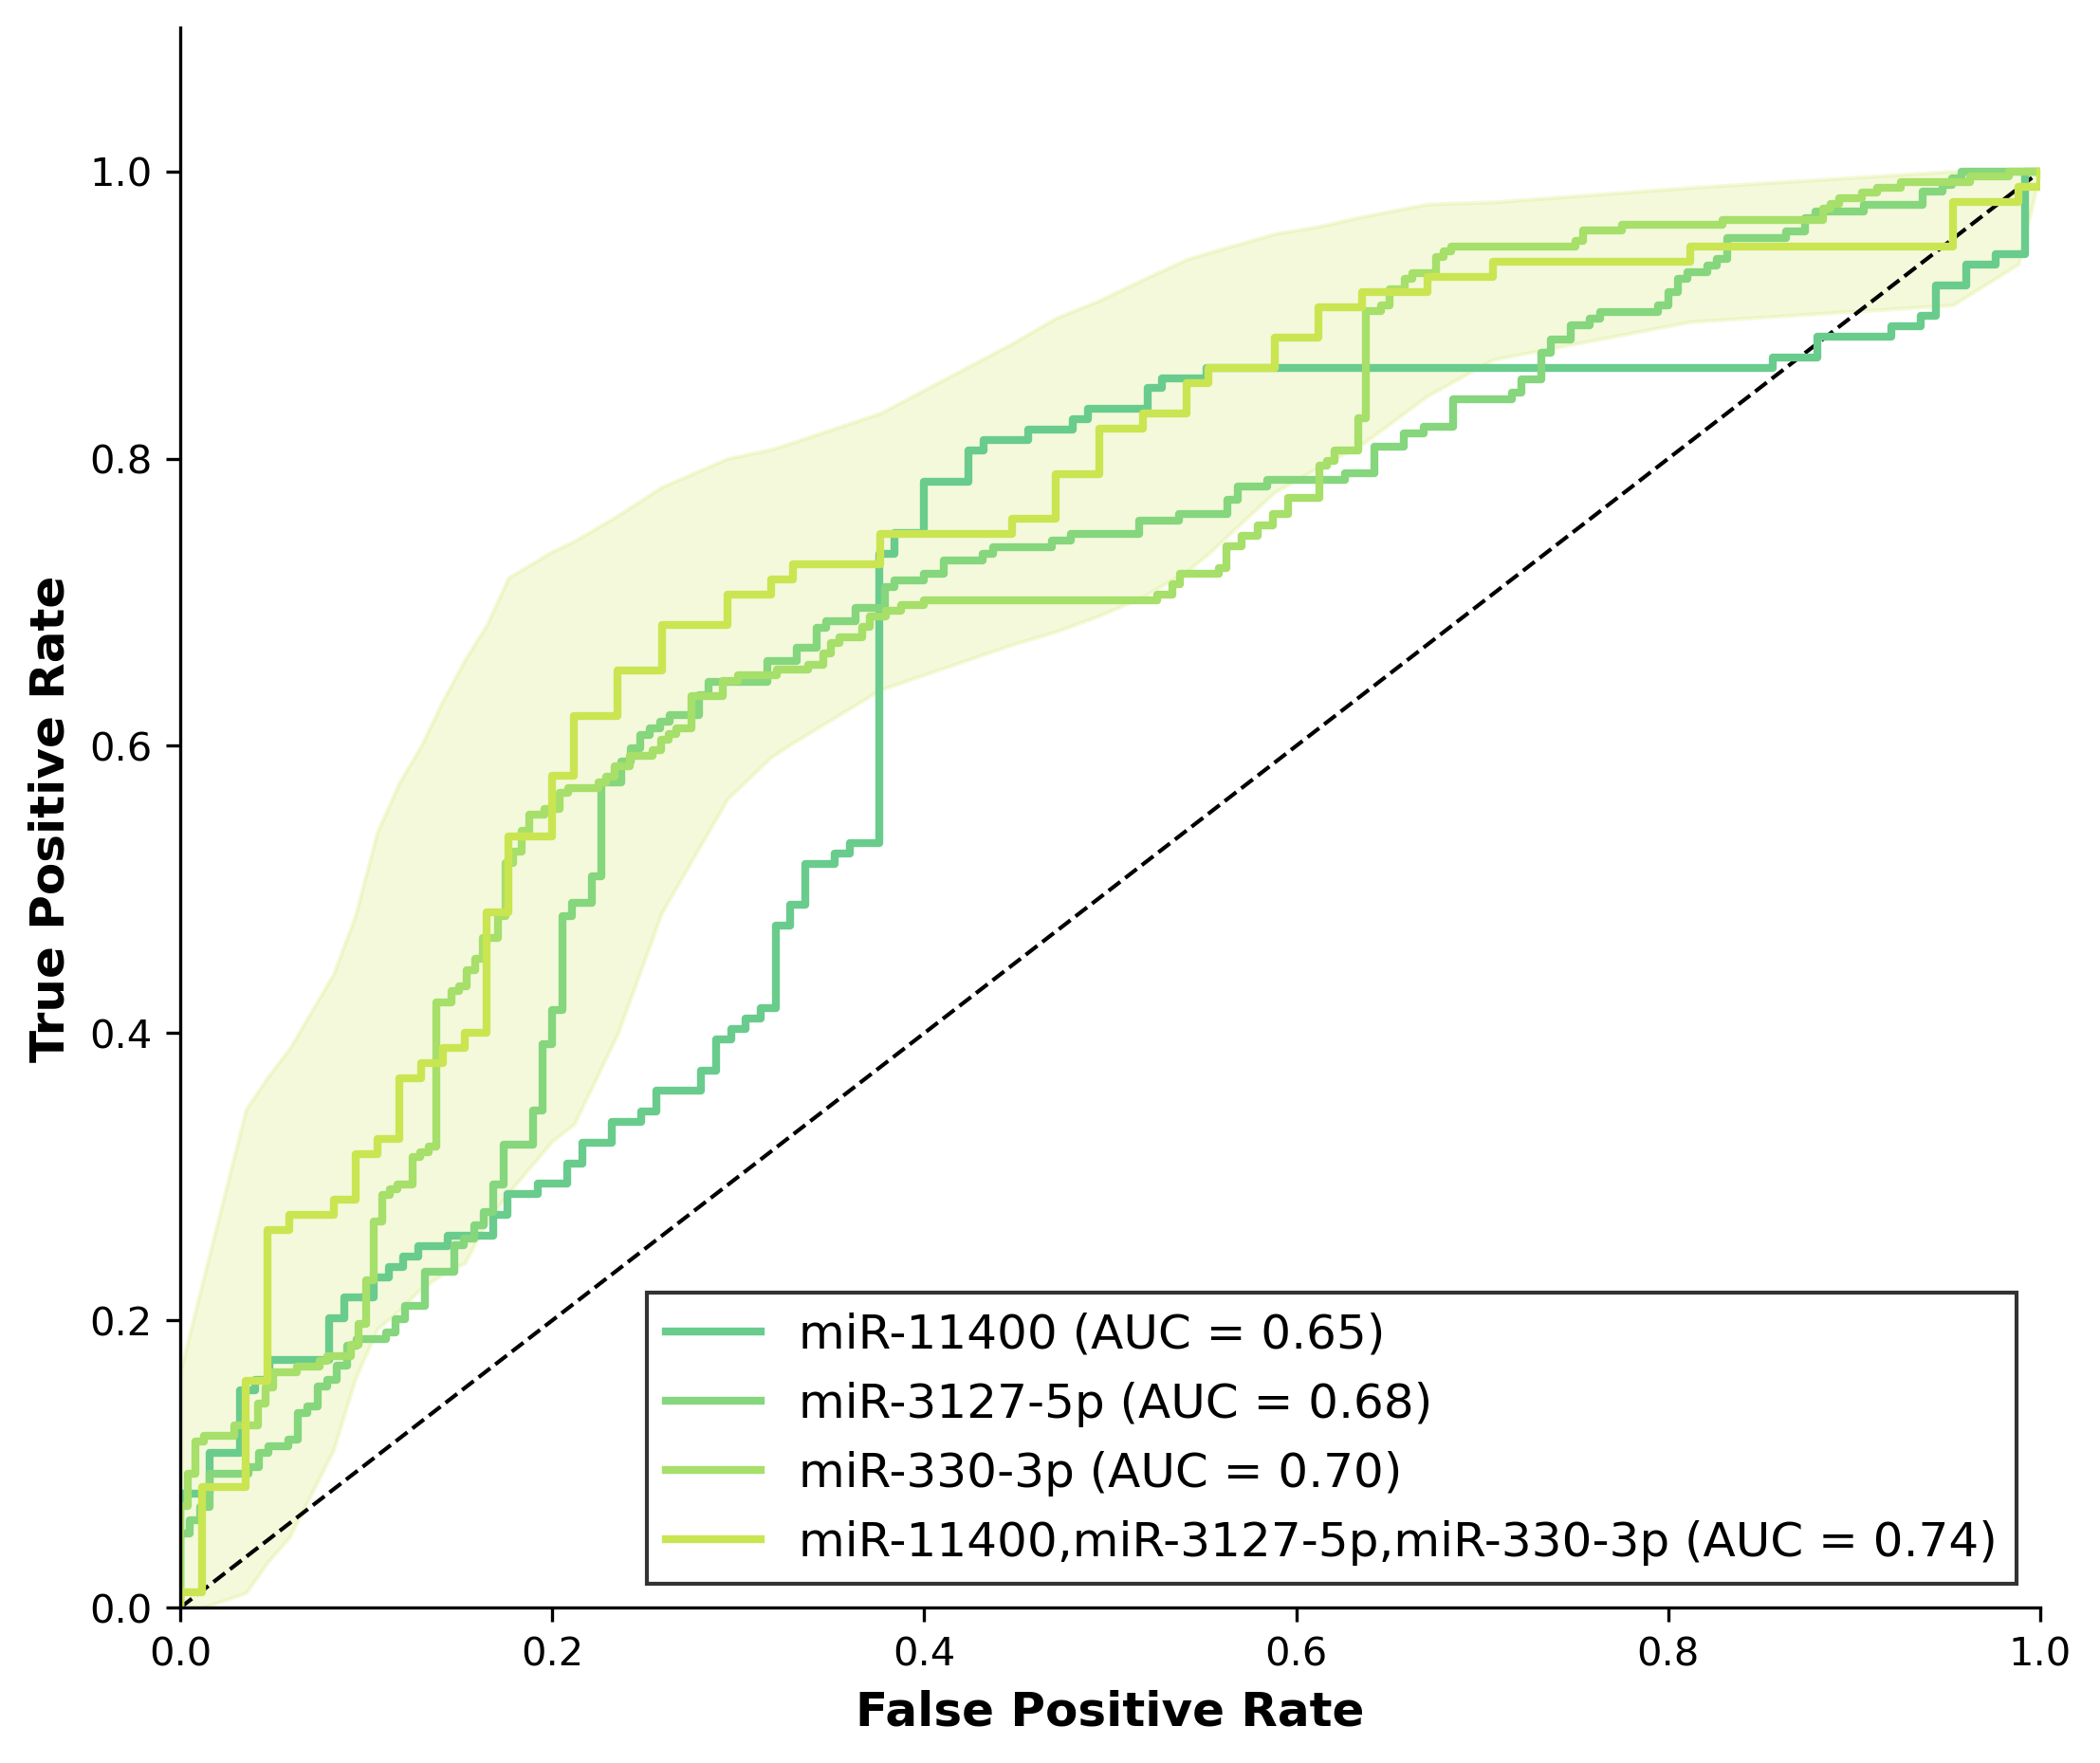

In [211]:
plotter(dataframe = gose_data,
        subset_results = individual_subset_results_gose,
        biomarker_key = 'hsa-miR-11400_gose,hsa-miR-3127-5p_gose,hsa-miR-330-3p_gose',
        dependent_variable = {'dv': 'gose_dichotimized',
                              'dv_1': 0, 
                              'dv_2': 1, 
                              'dv_1_name': 'IR', 
                              'dv_2_name': 'CR'
                              },
        plots = ['roc_aggregated'],
        biomarkers = ['hsa-miR-330-3p_dx', 'hsa-miR-3127-5p_dx', 'hsa-miR-301a-3p_dx', 'hsa-miR-197-5p_dx', 'hsa-miR-11400_dx'],
        plot_details = {'roc_aggregated': 
                        {'figsize': [190, 160], 
                         'save': True, 
                         'save_location': r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/roc_aggregated_gose.svg'}}
        )

<h4>Visualizing biomarkers</h4>

(<Figure size 3070.87x2125.98 with 5 Axes>,
 [<Axes: title={'center': 'miR-330-3p'}, ylabel=' RC RNA-Seq (TMM normalized)'>,
  <Axes: title={'center': 'miR-3127-5p'}, ylabel=' RC RNA-Seq (TMM normalized)'>,
  <Axes: title={'center': 'miR-301a-3p'}, ylabel=' RC RNA-Seq (TMM normalized)'>,
  <Axes: title={'center': 'miR-197-5p'}, ylabel=' RC RNA-Seq (TMM normalized)'>,
  <Axes: title={'center': 'miR-11400'}, ylabel=' RC RNA-Seq (TMM normalized)'>])

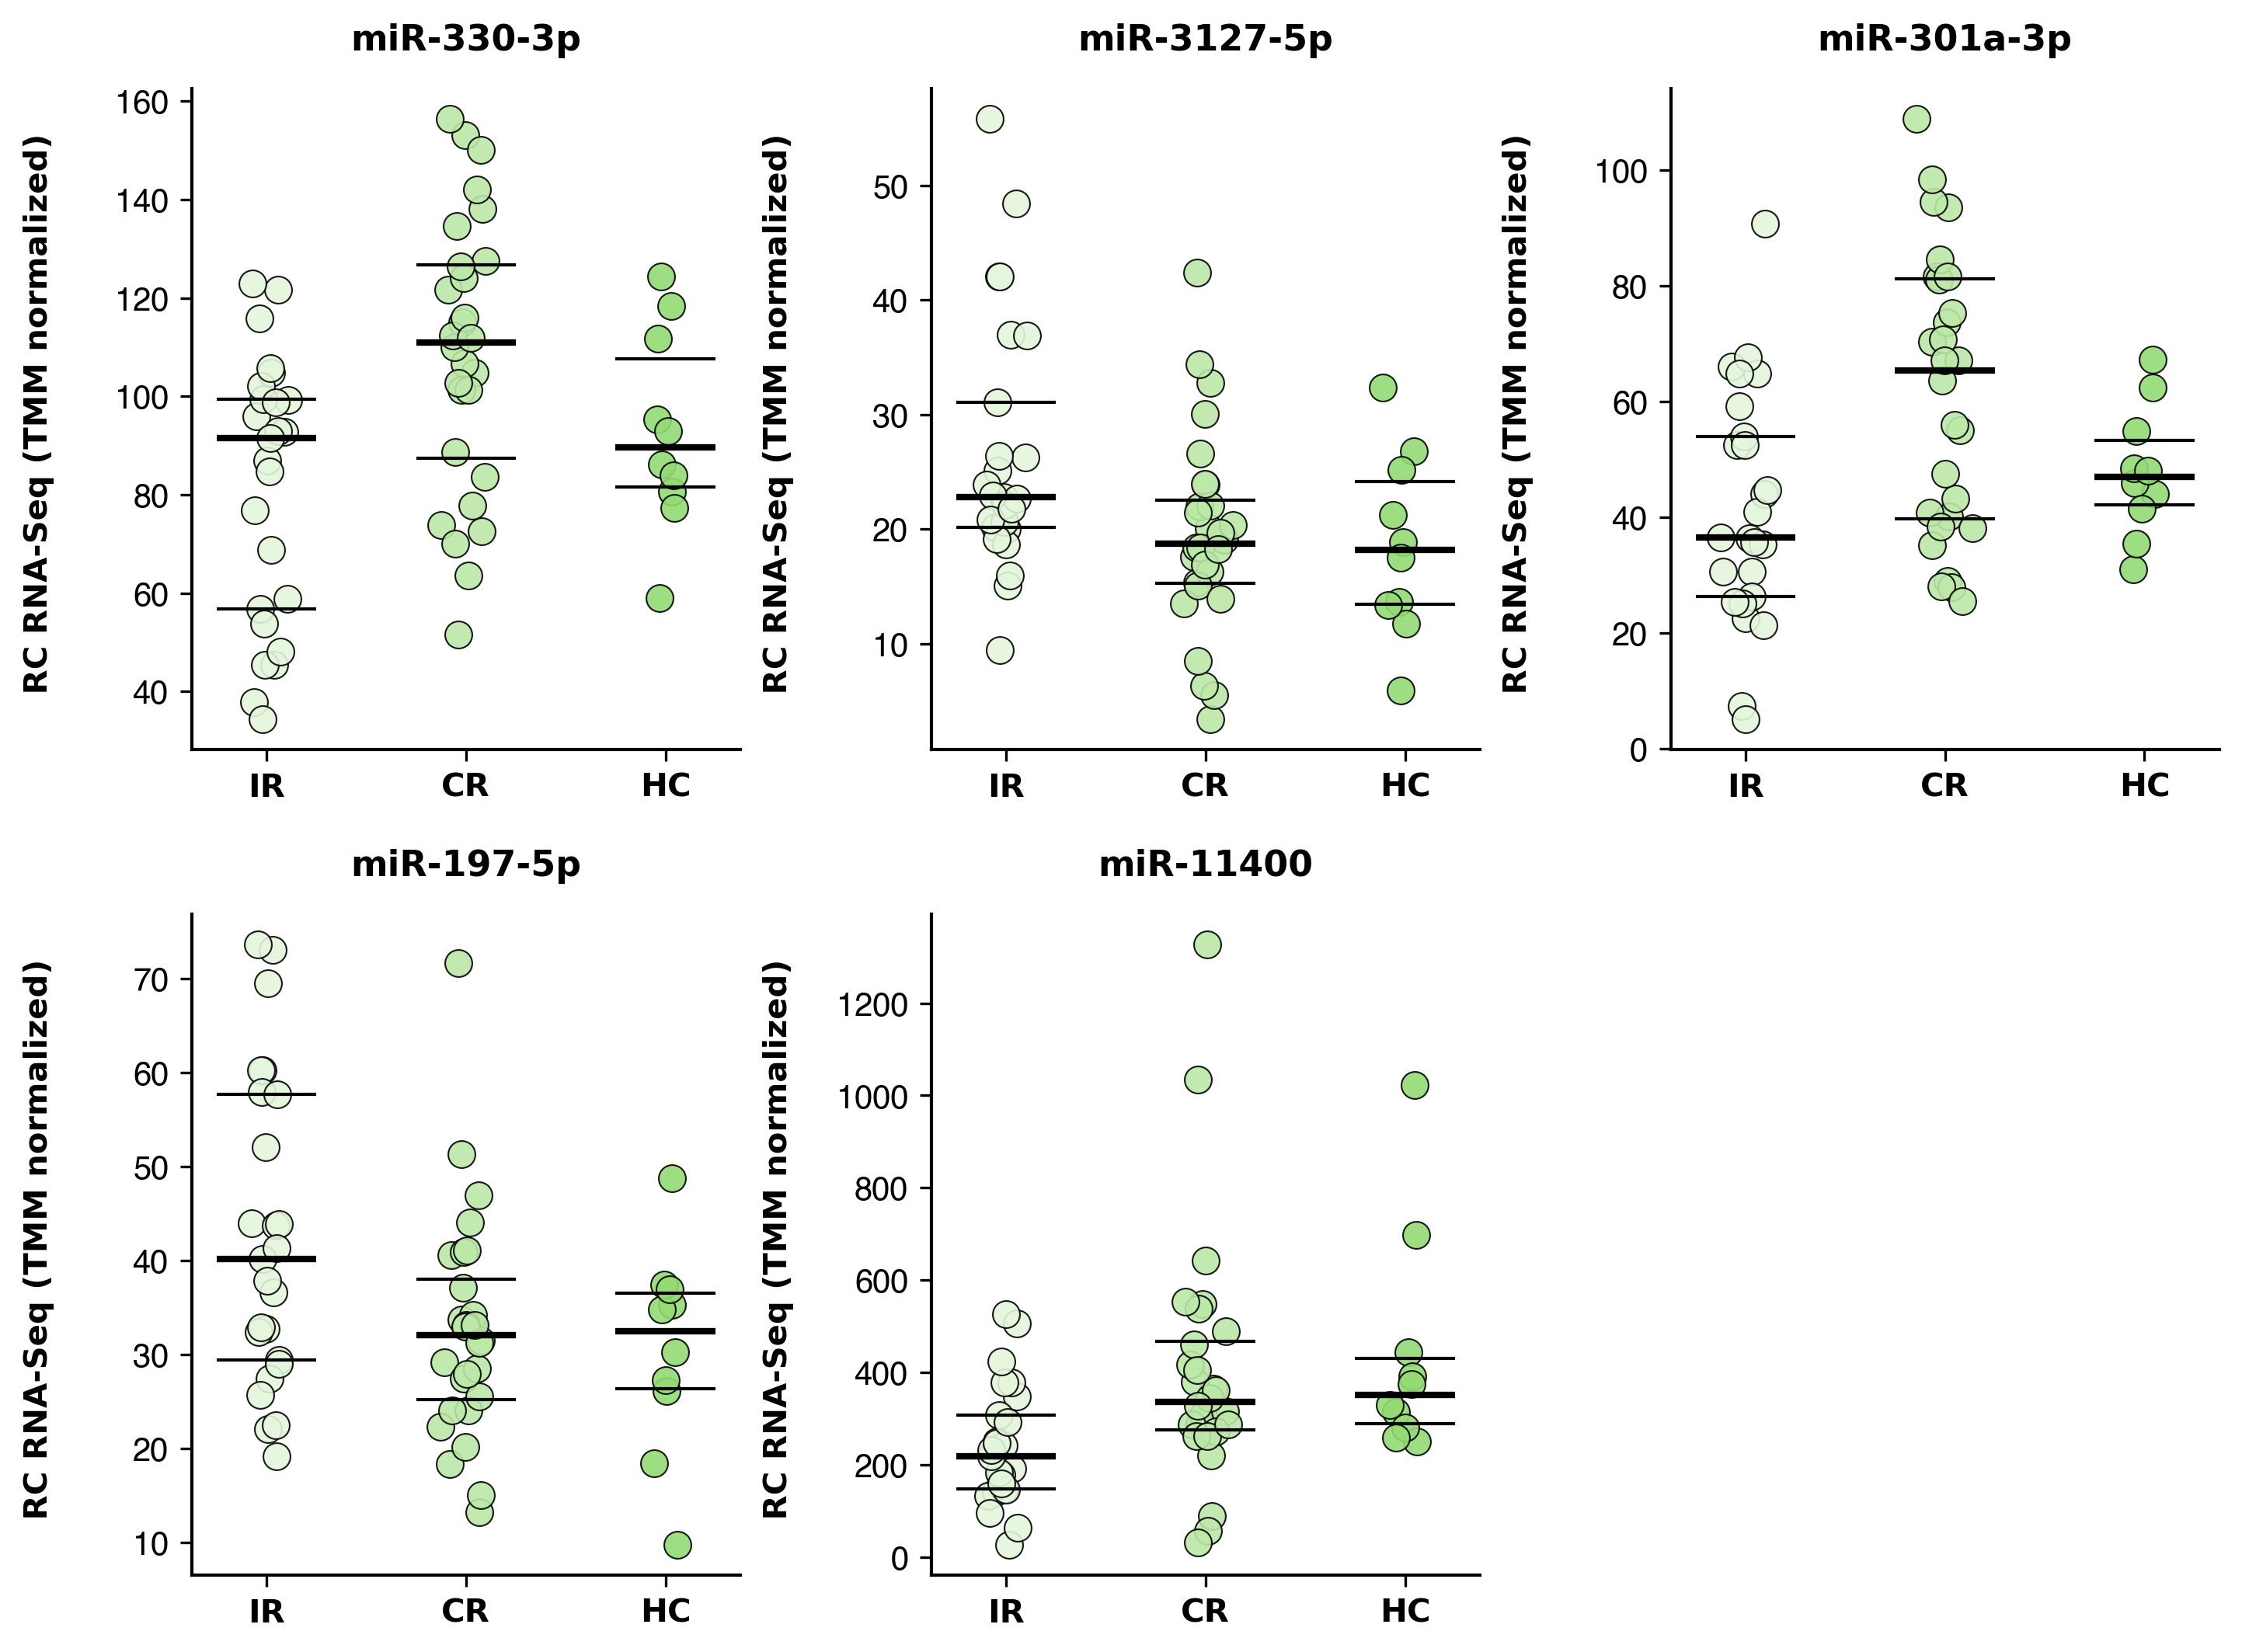

In [213]:
complete_recovery = data.iloc[0:64, :].loc[(data['group'] == 1) & (data['gose_dichotimized'] == 1) & (data['sample_id_ct'] !=5)]
incomplete_recovery = data.iloc[0:64, :].loc[(data['group'] == 1) & (data['gose_dichotimized'] == 0) & (data['sample_id_ct'] !=5)]
hc = data.iloc[0:64, :].loc[data['group'] == 0]
margin_dict = {'left': 0.1, 'right': 0.05, 'top': 0.05, 'bottom': 0.05, 'h_spacing': 0.08, 'v_spacing': 0.1}

plot_boxplot(df1 = incomplete_recovery, 
             df2 = complete_recovery, 
             df3 = hc, 
             biomarkers = ['hsa-miR-330-3p_dx', 'hsa-miR-3127-5p_dx', 'hsa-miR-301a-3p_dx', 'hsa-miR-197-5p_dx', 'hsa-miR-11400_dx'], 
             group_1_name = 'IR', 
             group_2_name = 'CR', 
             group_3_name = 'HC', 
             break_thresholds = None, 
             margin_dict = margin_dict,
             colors = None, 
             figsize = (260, 180), 
             figsize_unit = 'mm', 
             dpi=300, 
             save=True,
            save_location = r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/boxplot_ensemble_gose.svg'
             )

<h4>Correlation analysis</h4>

Bbox(x0=0.125, y0=0.13913265306122446, x1=0.9, y1=0.8508673469387755)


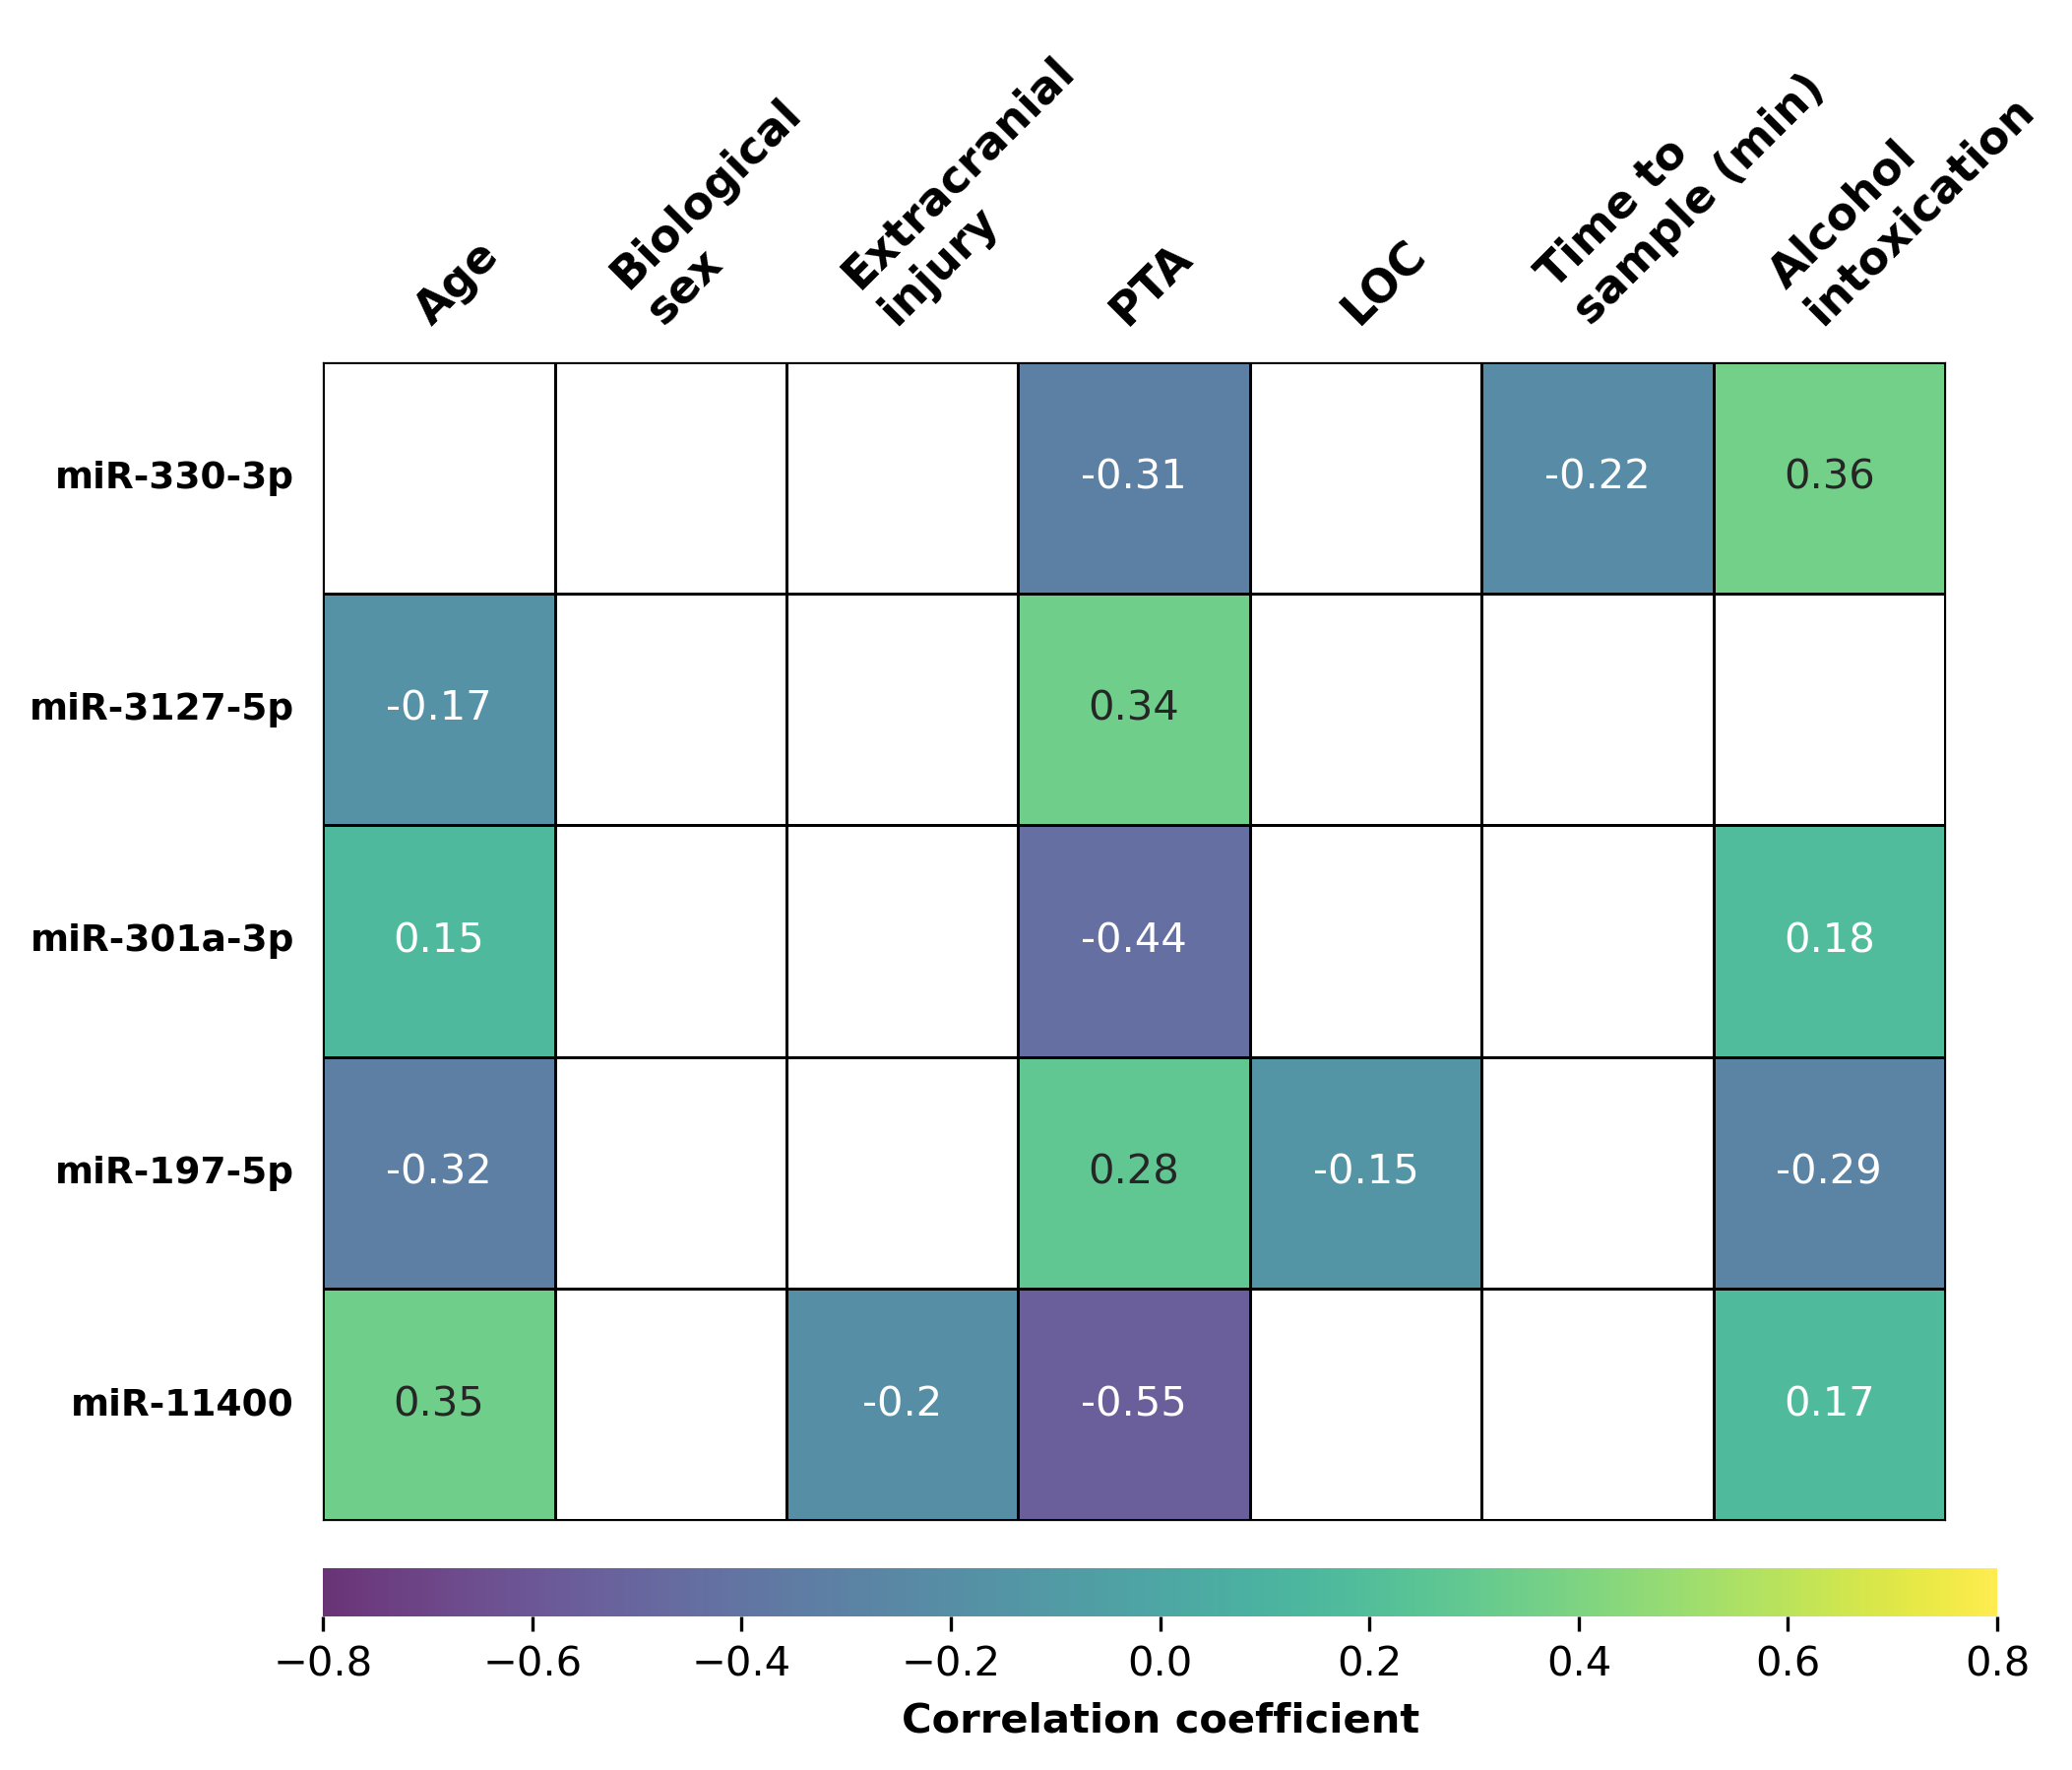

In [187]:
exploratory_variables = {'age':1,'gender':2, 'extracranial_dicho': 2, 'pta_dicho': 2, 'loc_dicho': 2, 'time_to_v1_minutes':1, 'alcohol_intoxication': 2}
mirna = {'hsa-miR-330-3p_dx': 0, 'hsa-miR-3127-5p_dx': 0, 'hsa-miR-301a-3p_dx': 0, 'hsa-miR-197-5p_dx': 0, 'hsa-miR-11400_dx': 0}
ytick_labels = ['miR-330-3p', 'miR-3127-5p', 'miR-301a-3p', 'miR-197-5p', 'miR-11400']
xtick_labels = ['Age', 'Biological\nsex', 'Extracranial\ninjury', 'PTA', 'LOC', 'Time to\nsample (min)', 'Alcohol\nintoxication']
p_list = makeHeatmap(gose_data, exploratory_variables, mirna, xtick_labels, ytick_labels, spec=True, saveFig=True, name=r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/corr_analysis_gose.svg', covar=[], covar_variables=[], figsize=[180, 140])

<h4>Plotting a venn diagram</h4>

Region 100 center: Point2D(-0.1822418550660543, 0.1052173840800032)
Region 010 center: Point2D(0.18224185506605425, 0.1052173840800032)
Region 001 center: Point2D(-2.7755575615628914e-17, -0.2104347681600064)
Region 110 does not exist in this diagram.
Region 101 does not exist in this diagram.
Region 011 does not exist in this diagram.
Region 111 does not exist in this diagram.


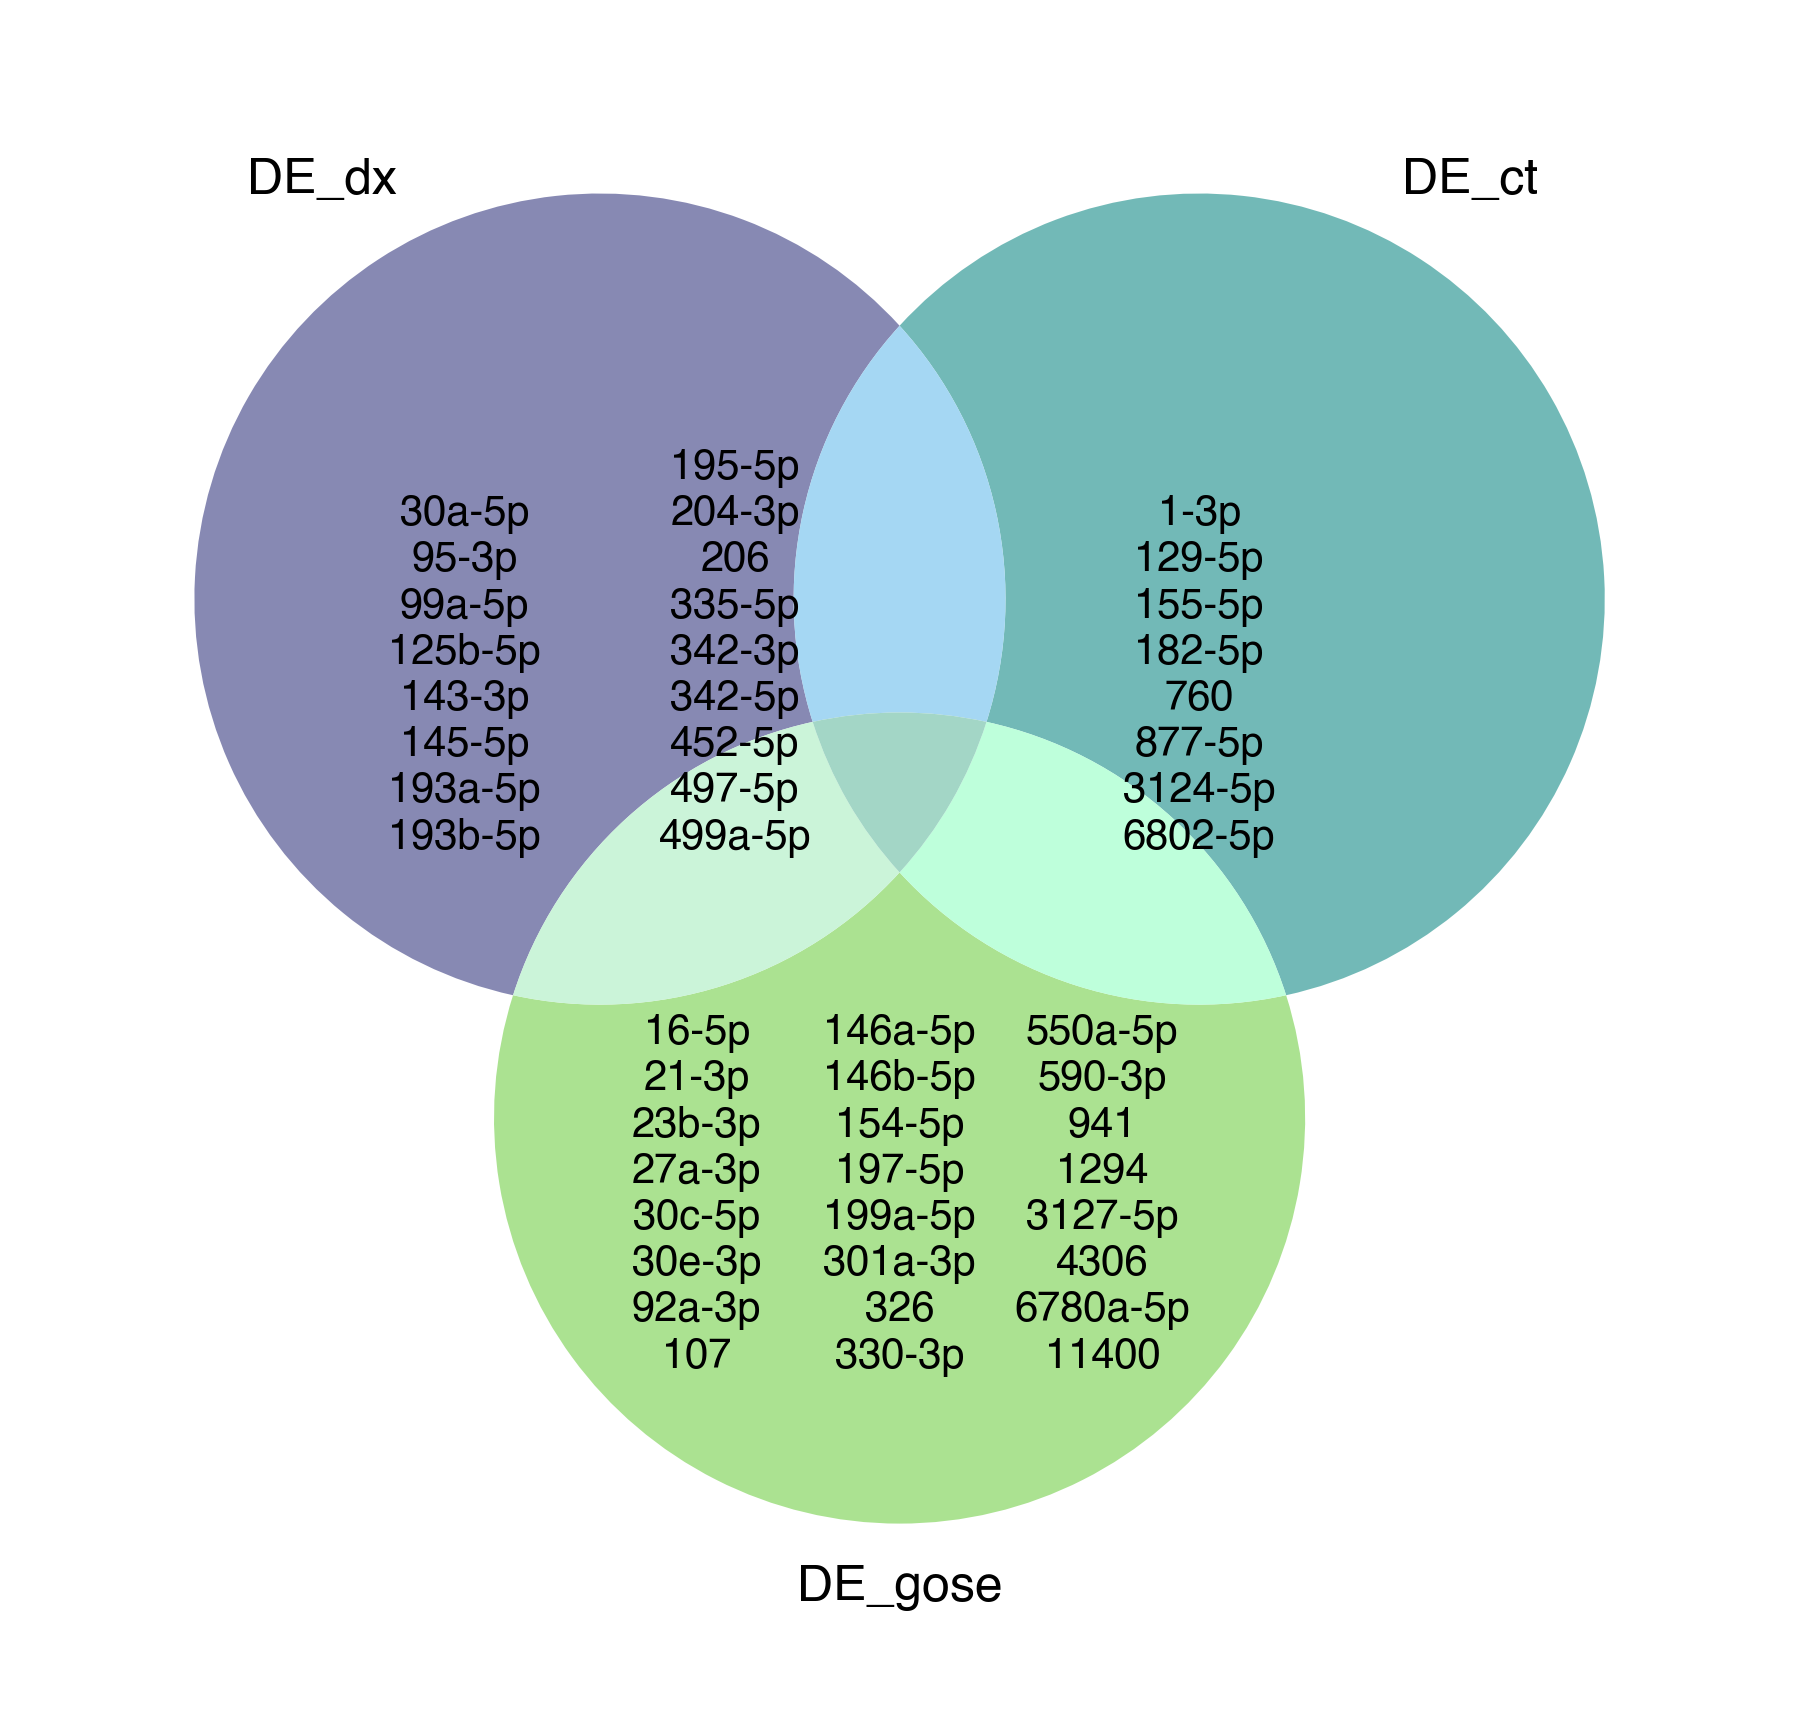

In [327]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm

DEFAULT_LINE_HEIGHT = 14 #In pixels

# Define your sets
DE_dx_list = ['30a-5p','95-3p', '99a-5p','125b-5p', '143-3p','145-5p', '193a-5p', '193b-5p', '195-5p','204-3p',   '206','335-5p', '342-3p', '342-5p', '452-5p', '497-5p','499a-5p']
DE_ct_list = ['1-3p','129-5p', '155-5p','182-5p','760','877-5p','3124-5p', '6802-5p']
DE_gose_list = ['16-5p',  '21-3p', '23b-3p', '27a-3p','30c-5p','30e-3p', '92a-3p', '107', '146a-5p', '146b-5p','154-5p','197-5p', '199a-5p', '301a-3p','326',  '330-3p',  '550a-5p','590-3p',  '941', '1294','3127-5p','4306','6780a-5p', '11400']

set1 = set(DE_dx_list)
set2 = set(DE_ct_list)
set3 = set(DE_gose_list)

def lighten_color(color, amount=0.5):
    """
    Lightens the given color by mixing it with white.
    Input can be matplotlib color string, hex string, or RGB tuple.
    amount=0 returns original color, amount=1 returns white.
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = np.array(mc.to_rgb(c))
    white = np.array([1, 1, 1])
    return tuple((1 - amount) * c + amount * white)

viridis_colors = [plt.cm.viridis(0.2), plt.cm.viridis(0.5), plt.cm.viridis(0.8)]
# Lighten the colors
lightened_colors = [lighten_color(color, 0.3) for color in viridis_colors]


figsize_inches = (190 / 25.4, 190 / 25.4)

plt.figure(figsize=figsize_inches, dpi=300)

# Create the Venn diagram
venn = venn3(subsets=(set1, set2, set3), set_labels=('DE_dx', 'DE_ct', 'DE_gose'), layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1, 1, 0.1, 1, 0.1, 0.1, 0.1), normalize_to=0.5), set_colors=lightened_colors, alpha=0.9)

# Define region IDs and their corresponding set operations
region_defs = {
    '100': set1 - set2 - set3,
    '010': set2 - set1 - set3,
    '001': set3 - set1 - set2,
    '110': (set1 & set2) - set3,
    '101': (set1 & set3) - set2,
    '011': (set2 & set3) - set1,
    '111': set1 & set2 & set3
}

region_ids = ['100', '010', '001', '110', '101', '011', '111']
region_centers = {}

for item in range(0, 7):
    region_id = region_ids[item]
    label = venn.get_label_by_id(region_id)
    label_text = label.get_text()

    if label_text != '0':
        center = venn.get_circle_center(item)
        radius = venn.get_circle_radius(item)
        region_centers[region_ids[item]] = [center, radius]
        print(f"Region {region_id} center: {center}")
    else:
        label.set_text('')
        print(f"Region {region_id} does not exist in this diagram.")

def get_annotation_coords(region_centers, region_id, elements, original_lists):
    region_details = region_centers[region_id][0]
    radius = region_centers[region_id][1]
    x = region_details.x
    y = region_details.y
    
    # Get the ordered elements based on the region
    ordered_elements = []
    if region_id == '100':  # Only in set1
        ordered_elements = [e for e in original_lists[0] if e in elements]
    elif region_id == '010':  # Only in set2
        ordered_elements = [e for e in original_lists[1] if e in elements]
    elif region_id == '001':  # Only in set3
        ordered_elements = [e for e in original_lists[2] if e in elements]
    elif region_id == '110':  # In set1 and set2
        ordered_elements = [e for e in original_lists[0] if e in elements]
    elif region_id == '101':  # In set1 and set3
        ordered_elements = [e for e in original_lists[0] if e in elements]
    elif region_id == '011':  # In set2 and set3
        ordered_elements = [e for e in original_lists[1] if e in elements]
    elif region_id == '111':  # In all sets
        ordered_elements = [e for e in original_lists[0] if e in elements]
    
    elements_count = len(ordered_elements)
    loops = round(elements_count / 8)
    annotations = []
    coordinates = []
    
    for _ in range(0, loops):
        starting_index = _ * 8
        if _ == loops - 1:  # the final loop
            annotation = '\n'.join(ordered_elements[starting_index:])
            annotations.append(annotation)
        else:
            annotation = '\n'.join(ordered_elements[starting_index:(starting_index + 8)])
            annotations.append(annotation)

    start_x = x - radius
    end_x = x + radius
    distance = end_x - start_x
    segments = loops + 1
    segment_distance = distance / segments

    for _ in range(1, loops + 1):
        temp_coords = []
        temp_coords.append(start_x + (_ * segment_distance))
        temp_coords.append(y - (0.0378 * 4))
        coordinates.append(temp_coords)
    
    return [coordinates, annotations, loops]

# Set labels for each region if the label exists
for region_id, elements in region_defs.items():
    label = venn.get_label_by_id(region_id)
    label_text = label.get_text()
    if label_text != '':
        label.set_text('')
        coordinates, annotations, loops = get_annotation_coords(region_centers, region_id, elements, [DE_dx_list, DE_ct_list, DE_gose_list])

        for _ in range(0, loops):
            plt.annotate(annotations[_], xy=(coordinates[_][0], coordinates[_][1]), fontsize=10, ha='center', fontweight='bold')


# Display the diagram
plt.savefig(r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/venn_diagram_mirna.svg', dpi=300, bbox_inches='tight')
plt.show()

